This page is deciated to visualize the distribution of $\hat R_{\nu}$ for various distributions.

In [ ]:
import numpy as np
from google.colab import drive
from matplotlib.lines import Line2D
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def plot_transformed_rhat_with_f(
    df,
    distribution_name,
    K,
    M,
    warmups,
    bins=30
):

    if len(warmups) != 9:
        raise ValueError(
            "warmups must contain exactly 9 Warmup Length values."
        )

    df_num = K - 1
    df_den = K * (M - 1)

    f_q05 = f.ppf(
        0.05,
        df_num,
        df_den
    )

    f_q95 = f.ppf(
        0.95,
        df_num,
        df_den
    )

    f_q999 = f.ppf(
        0.999,
        df_num,
        df_den
    )

    # --------------------------------------------------
    # Create 3 x 3 subplot grid
    # --------------------------------------------------
    fig, axes = plt.subplots(
        3,
        3,
        figsize=(18, 14),
        dpi=150,
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    # --------------------------------------------------
    # Loop through warmup lengths
    # --------------------------------------------------
    for ax, warmup in zip(axes, warmups):

        # ----------------------------------------------
        # Select rows for this warmup length
        # ----------------------------------------------
        warmup_data = df.loc[
            df["Warmup Length"] == warmup
        ]

        # ----------------------------------------------
        # Select Rhat values
        # ----------------------------------------------
        rhat_data = warmup_data[
            "Rhat"
        ].dropna()

        # ----------------------------------------------
        # Convert Rhat to NumPy floats
        #
        # Does NOT modify the DataFrame.
        # ----------------------------------------------
        rhat_values = np.asarray(
            [
                float(x)
                for x in rhat_data
            ],
            dtype=float
        )

        # ----------------------------------------------
        # Calculate average MSE
        # ----------------------------------------------
        mse_data = warmup_data[
            "MSE"
        ].dropna()

        mse_values = np.asarray(
            [
                float(x)
                for x in mse_data
            ],
            dtype=float
        )

        if len(mse_values) > 0:
            avg_mse = np.mean(mse_values)
        else:
            avg_mse = np.nan

        # ----------------------------------------------
        # Handle missing Rhat data
        # ----------------------------------------------
        if len(rhat_values) == 0:

            ax.set_title(
                f"Warmup Length = {warmup}"
            )

            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

            continue

        # ----------------------------------------------
        # Transform Rhat into F statistic
        #
        # F = (Rhat^2 - 1) * M
        # ----------------------------------------------
        f_values = (
            (rhat_values ** 2 - 1)
            * M
        )

        # ----------------------------------------------
        # Remove invalid values
        # ----------------------------------------------
        f_values = f_values[
            np.isfinite(f_values) &
            (f_values >= 0)
        ]

        # ----------------------------------------------
        # Determine individual x-axis range
        # ----------------------------------------------
        x_min = 0.0

        x_max = max(
            f_values.max(),
            f_q999
        )

        # Add 2% padding
        if x_max > x_min:
            x_max += 0.02 * (
                x_max - x_min
            )

        # ----------------------------------------------
        # Generate theoretical F PDF
        # ----------------------------------------------
        x = np.linspace(
            x_min,
            x_max,
            2000
        )

        y = f.pdf(
            x,
            df_num,
            df_den
        )

        # ----------------------------------------------
        # Empirical histogram
        # ----------------------------------------------
        ax.hist(
            f_values,
            bins=bins,
            density=True,
            alpha=0.6,
            edgecolor="black",
            label="Transformed Rhat"
        )

        # ----------------------------------------------
        # Theoretical F PDF
        # ----------------------------------------------
        ax.plot(
            x,
            y,
            linewidth=2.5,
            label=(
                f"F({df_num}, {df_den}) PDF"
            )
        )

        # ----------------------------------------------
        # 5th percentile
        # ----------------------------------------------
        ax.axvline(
            f_q05,
            linestyle="--",
            linewidth=1.5,
            label=f"5th = {f_q05:.3f}",
            c="red"
        )

        # ----------------------------------------------
        # 95th percentile
        # ----------------------------------------------
        ax.axvline(
            f_q95,
            linestyle="--",
            linewidth=1.5,
            label=f"95th = {f_q95:.3f}",
            c="red"
        )

        # ----------------------------------------------
        # Labels
        # ----------------------------------------------
        ax.set_xlabel(
            r"$(\hat{R}^2 - 1)M$"
        )

        ax.set_ylabel(
            "Density"
        )

        ax.set_title(
            f"Warmup Length = {warmup}"
        )

        # ----------------------------------------------
        # Display average MSE
        # ----------------------------------------------
        if np.isfinite(avg_mse):

            ax.text(
                0.97,
                0.95,
                f"Avg MSE = {avg_mse:.4g}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=11,
                bbox=dict(
                    boxstyle="round",
                    alpha=0.8
                )
            )

        else:

            ax.text(
                0.97,
                0.95,
                "Avg MSE = N/A",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=11
            )

        ax.grid(alpha=0.3)

    # --------------------------------------------------
    # Overall title
    # --------------------------------------------------
    fig.suptitle(
        f"Transformed Rhat and Theoretical F Distribution\n"
        f"Target Distribution: {distribution_name}",
        fontsize=18
    )

    # --------------------------------------------------
    # Shared legend
    # --------------------------------------------------
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=4
    )

    # --------------------------------------------------
    # Layout
    # --------------------------------------------------
    plt.tight_layout(
        rect=[0, 0, 1, 0.88]
    )

    plt.show()

**Necessary Parameter Setup**

In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# Transition kernel for short regime
repitition = 10
num_chains_short = 2048
num_super_chains = 16

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [ ]:
utility_link = '/content/drive/MyDrive/JHU Stuff/Capstone/Utility_Functions/histogram_Utility.py'
with open(utility_link) as f: exec(f.read())

In [ ]:
warmup_lengths = [
    10, 20, 30,
    40, 50, 100,
    200, 500, 1000
]

## **Paper Distributions**

In [ ]:
# IRT distribution
IRT_bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_constrained.pkl"
IRT_bjx_R_Hat_c_df = pd.read_pickle(IRT_bjx_R_hat_c_path)

IRT_bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/IRT_R_Hat_naive.pkl"
IRT_bjx_R_Hat_n_df = pd.read_pickle(IRT_bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")

BlackJAX implementation data Loaded!


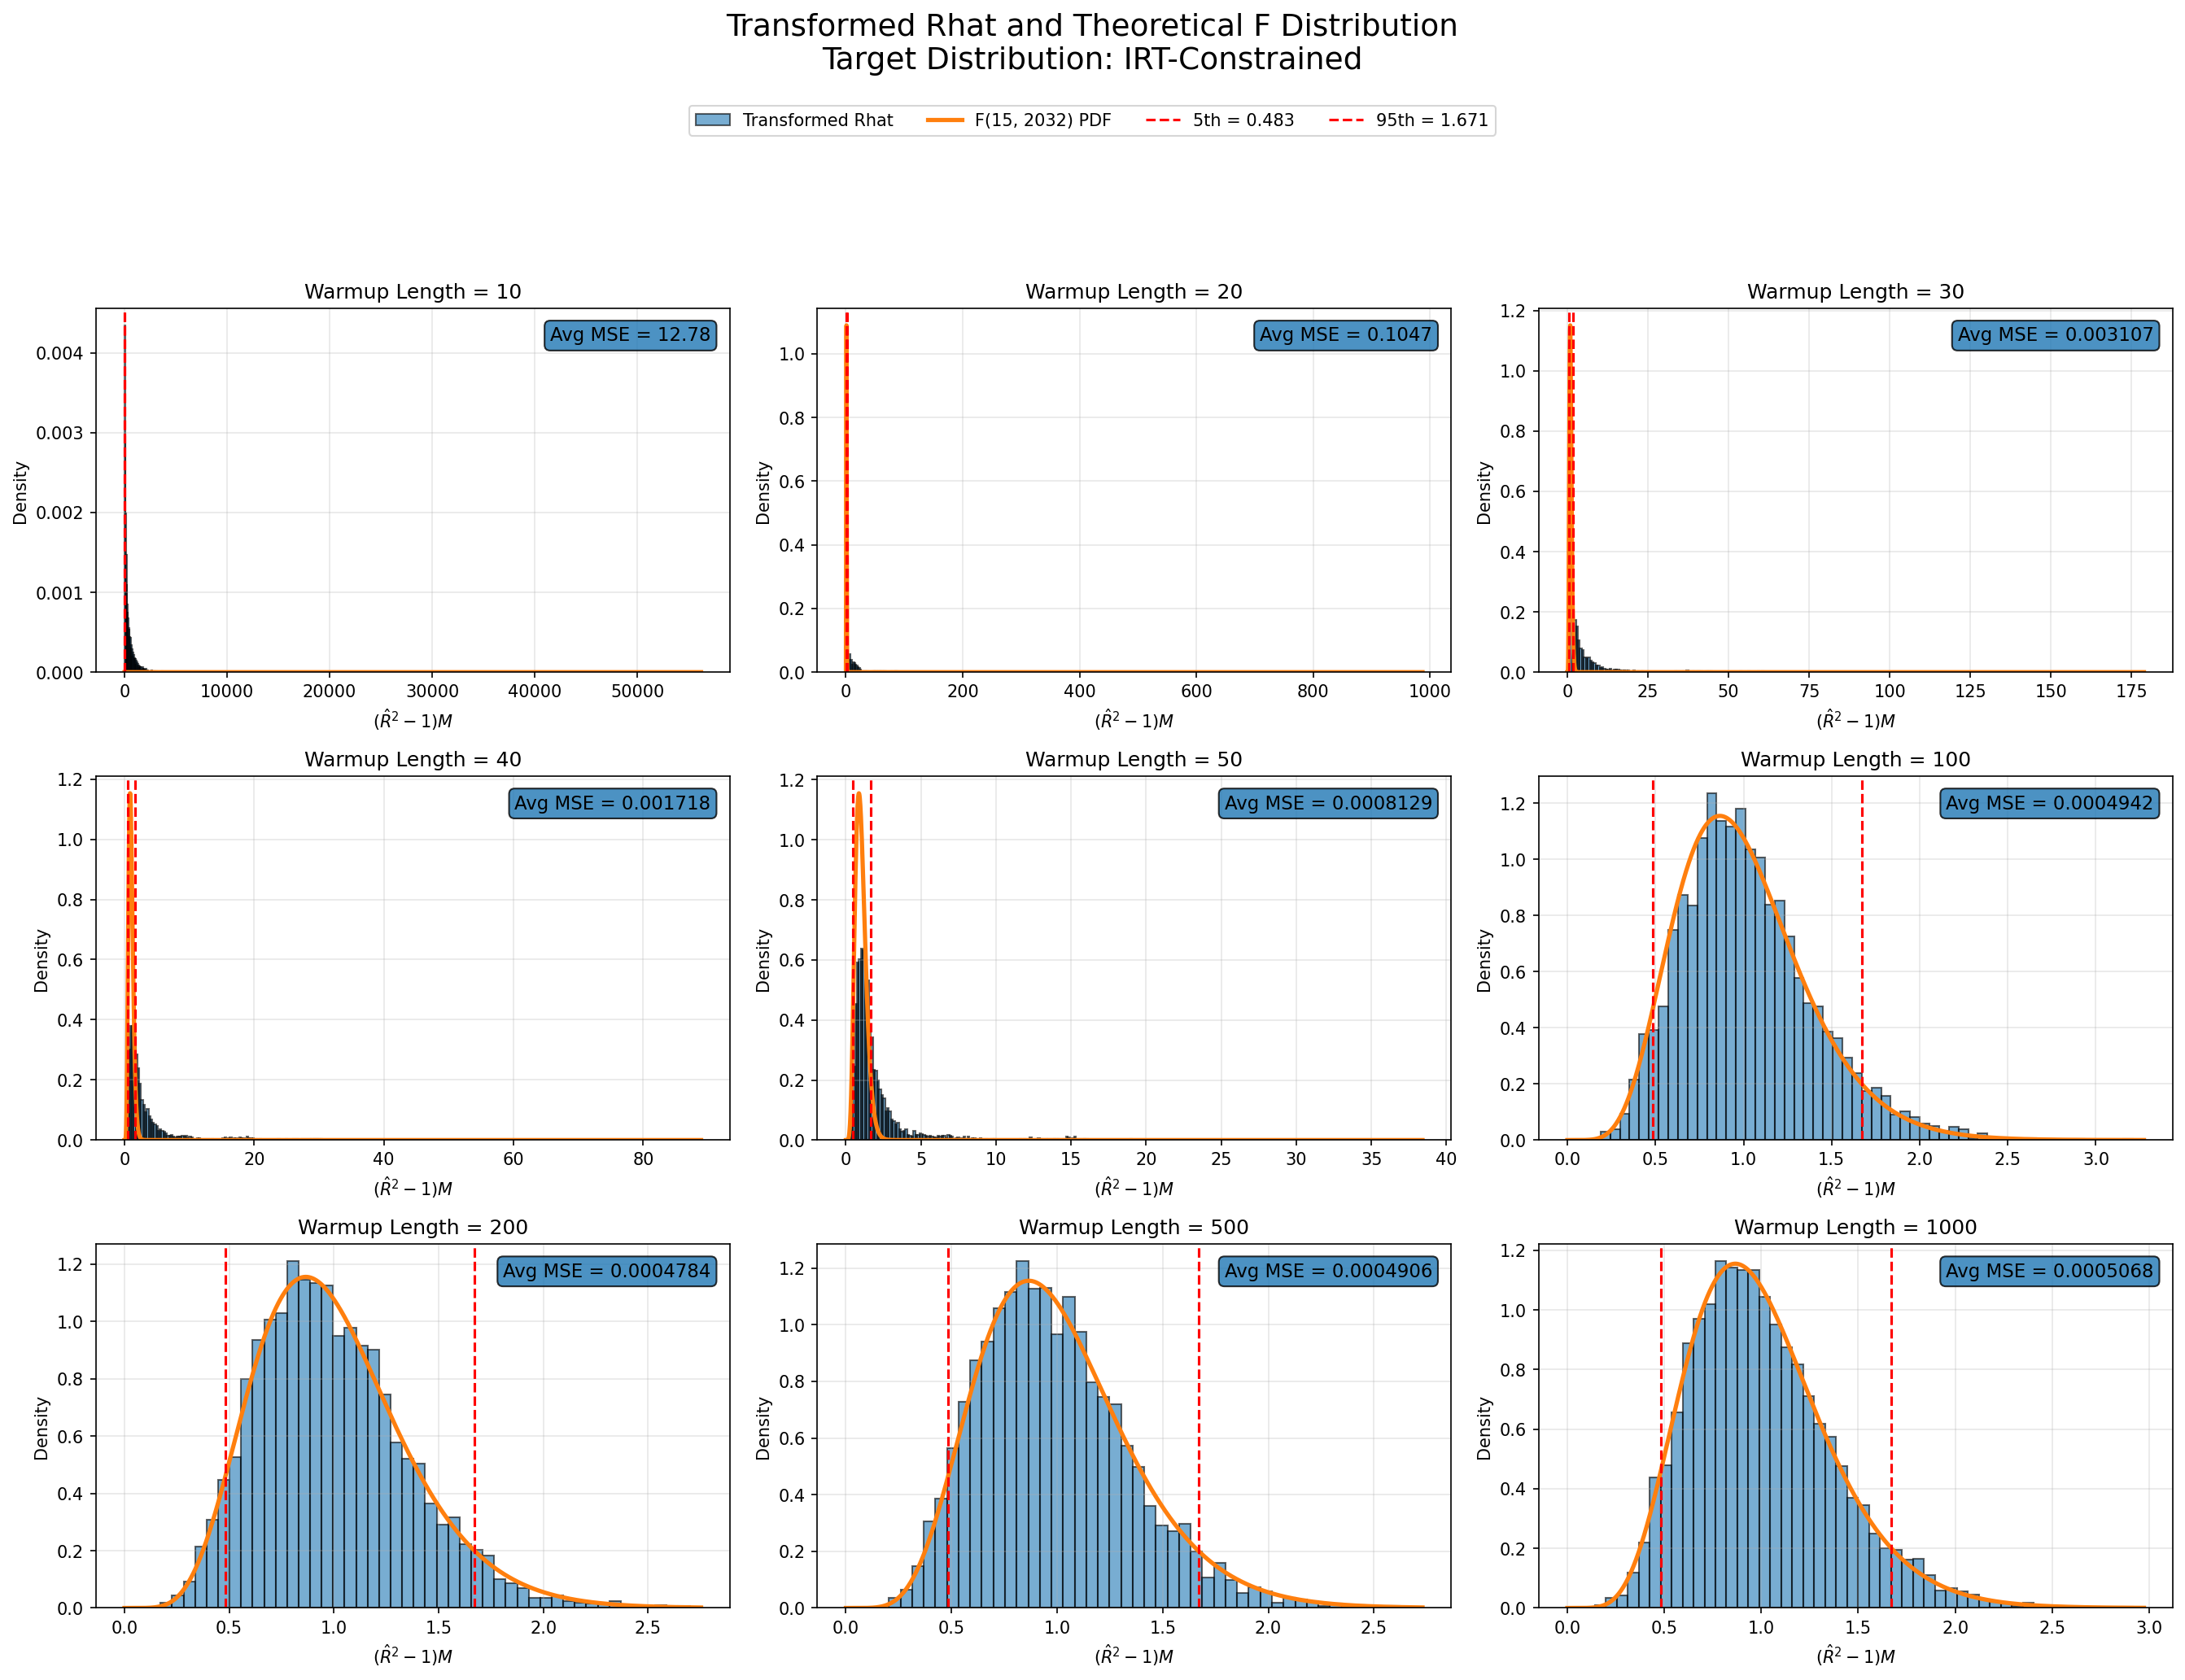

In [ ]:
plot_transformed_rhat_with_f(
    IRT_bjx_R_Hat_c_df,
    "IRT-Constrained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

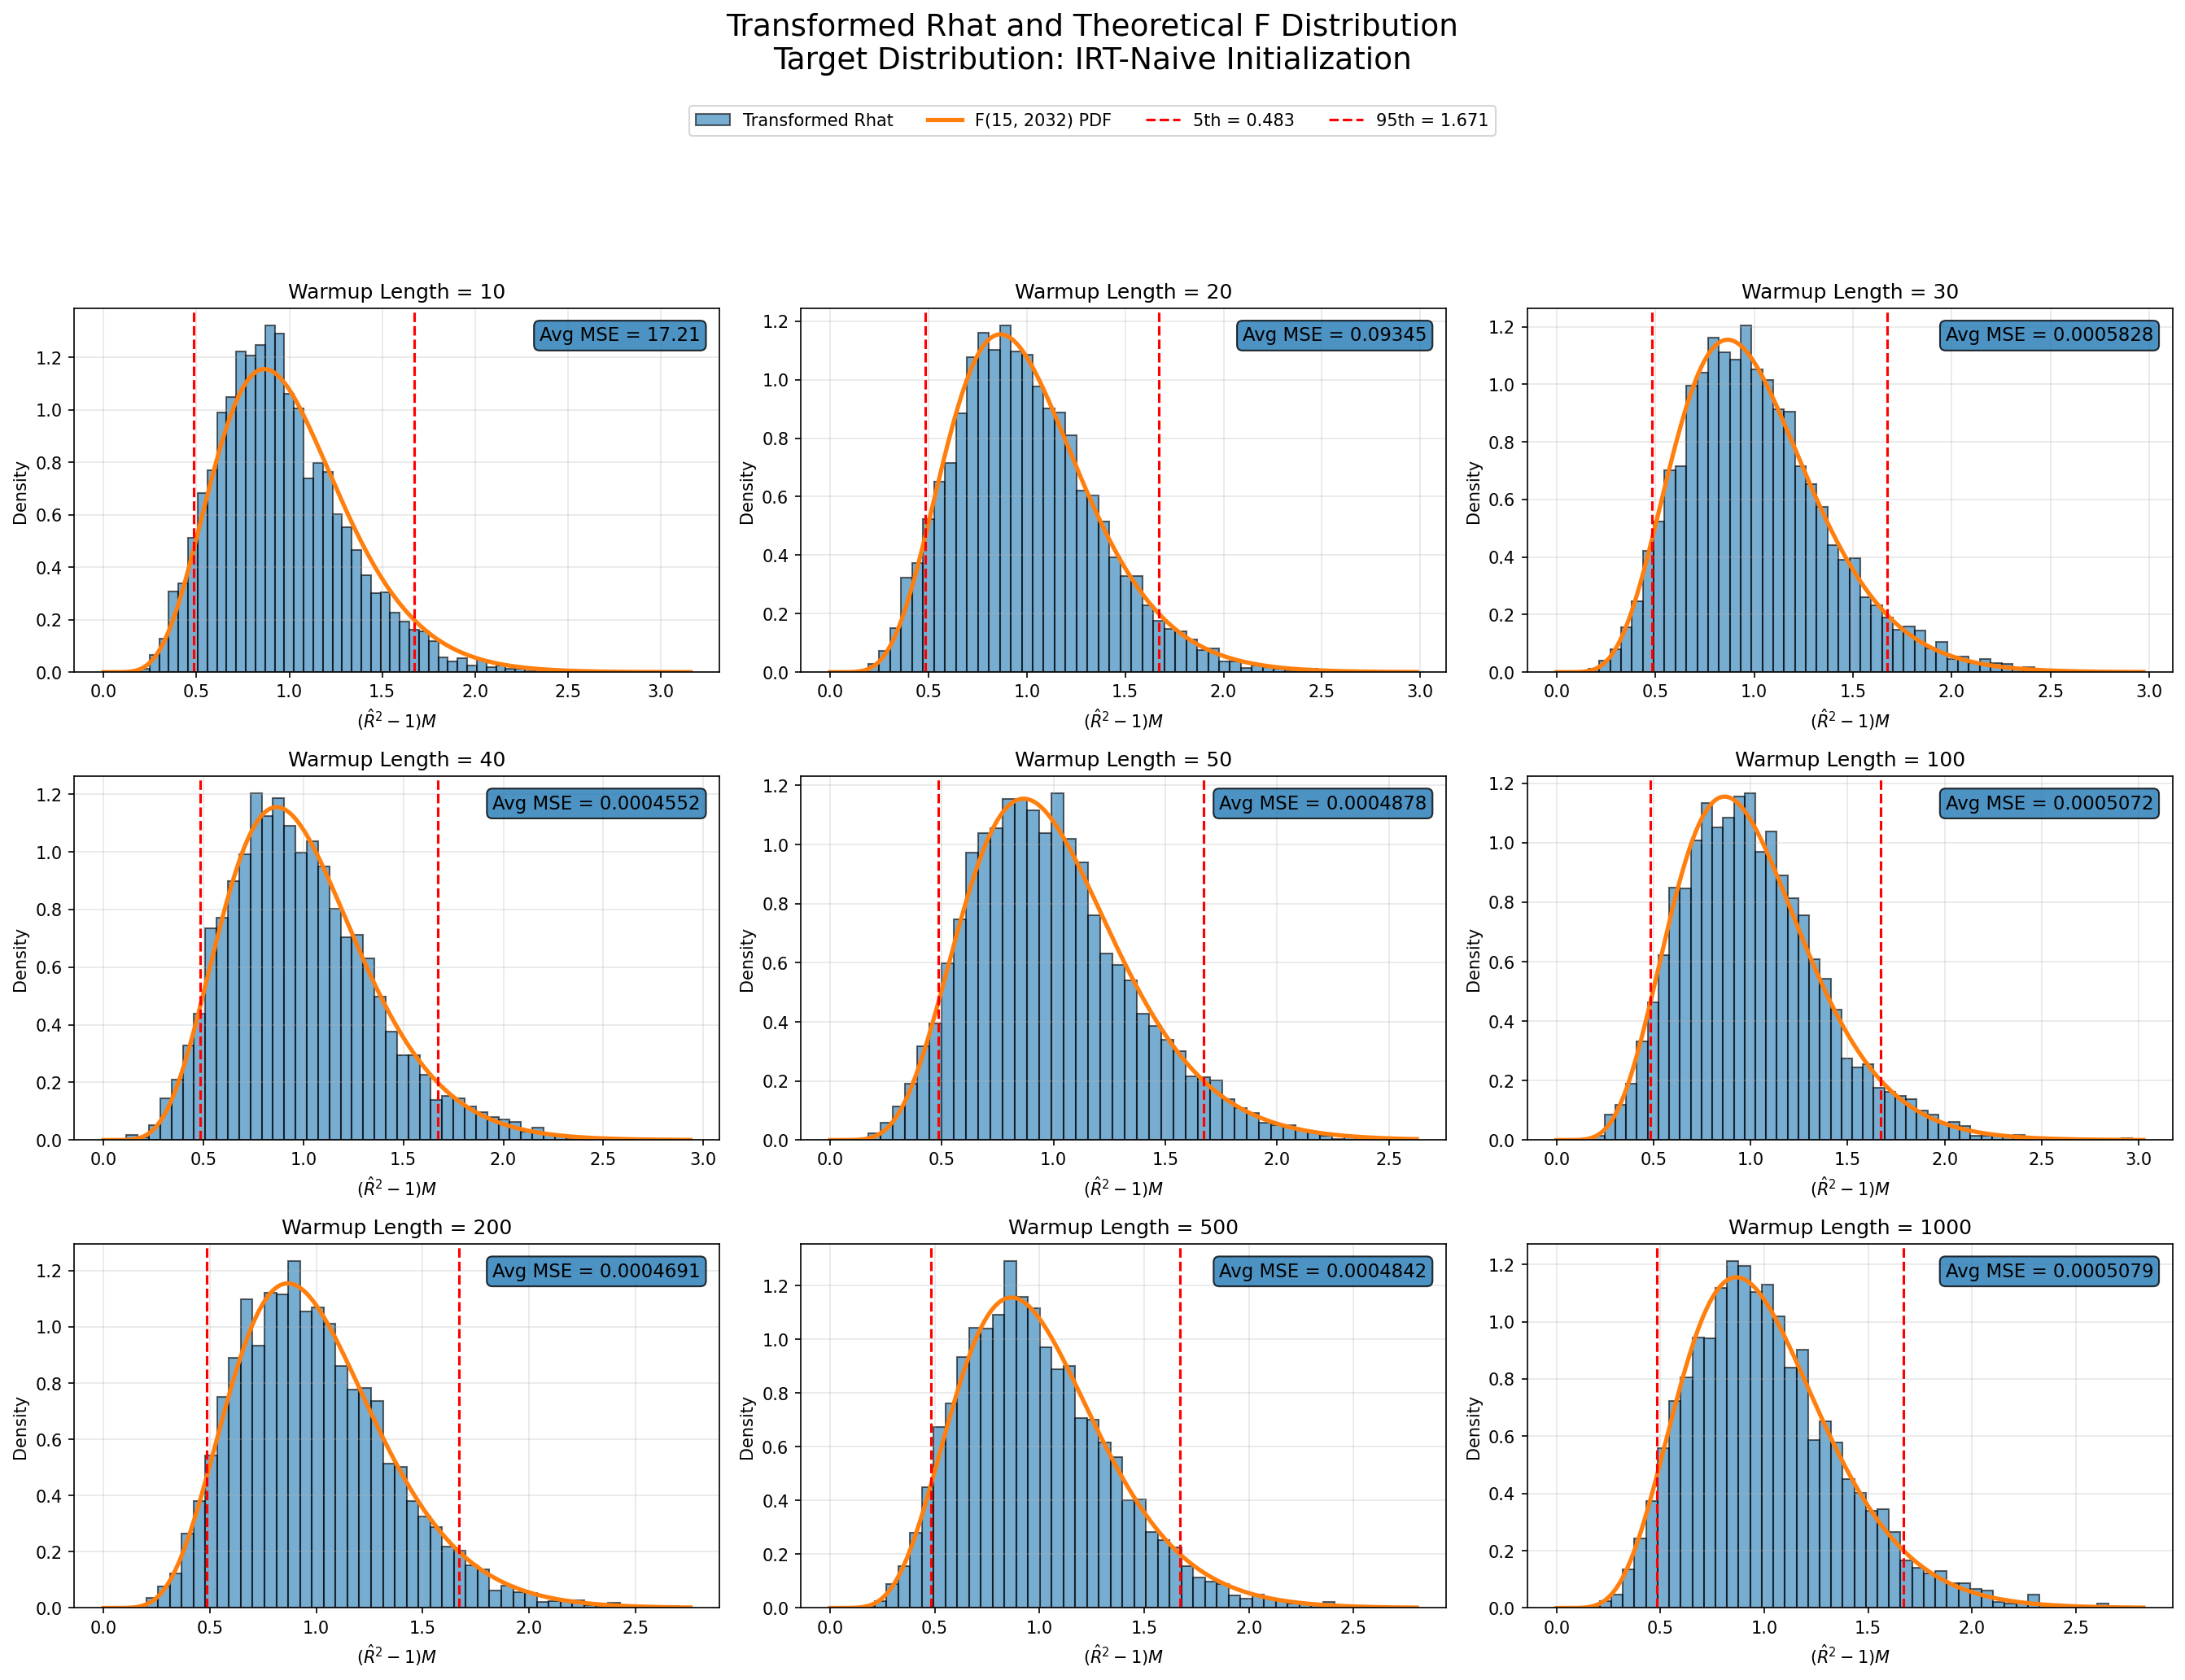

In [ ]:
plot_transformed_rhat_with_f(
    IRT_bjx_R_Hat_n_df,
    "IRT-Naive Initialization",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

In [ ]:
# Eight School Distritbution:
School_pf_R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/InitializationExperiment/School_R_Hat.pkl"
School_pf_R_Hat_c_df = pd.read_pickle(School_pf_R_Hat_c_path)

School_pf_R_Hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_PF_pkl_files/School_R_Hat.pkl"
School_pf_R_Hat_n_df = pd.read_pickle(School_pf_R_Hat_n_path)
print("PathFinder implementation data Loaded!")

PathFinder implementation data Loaded!


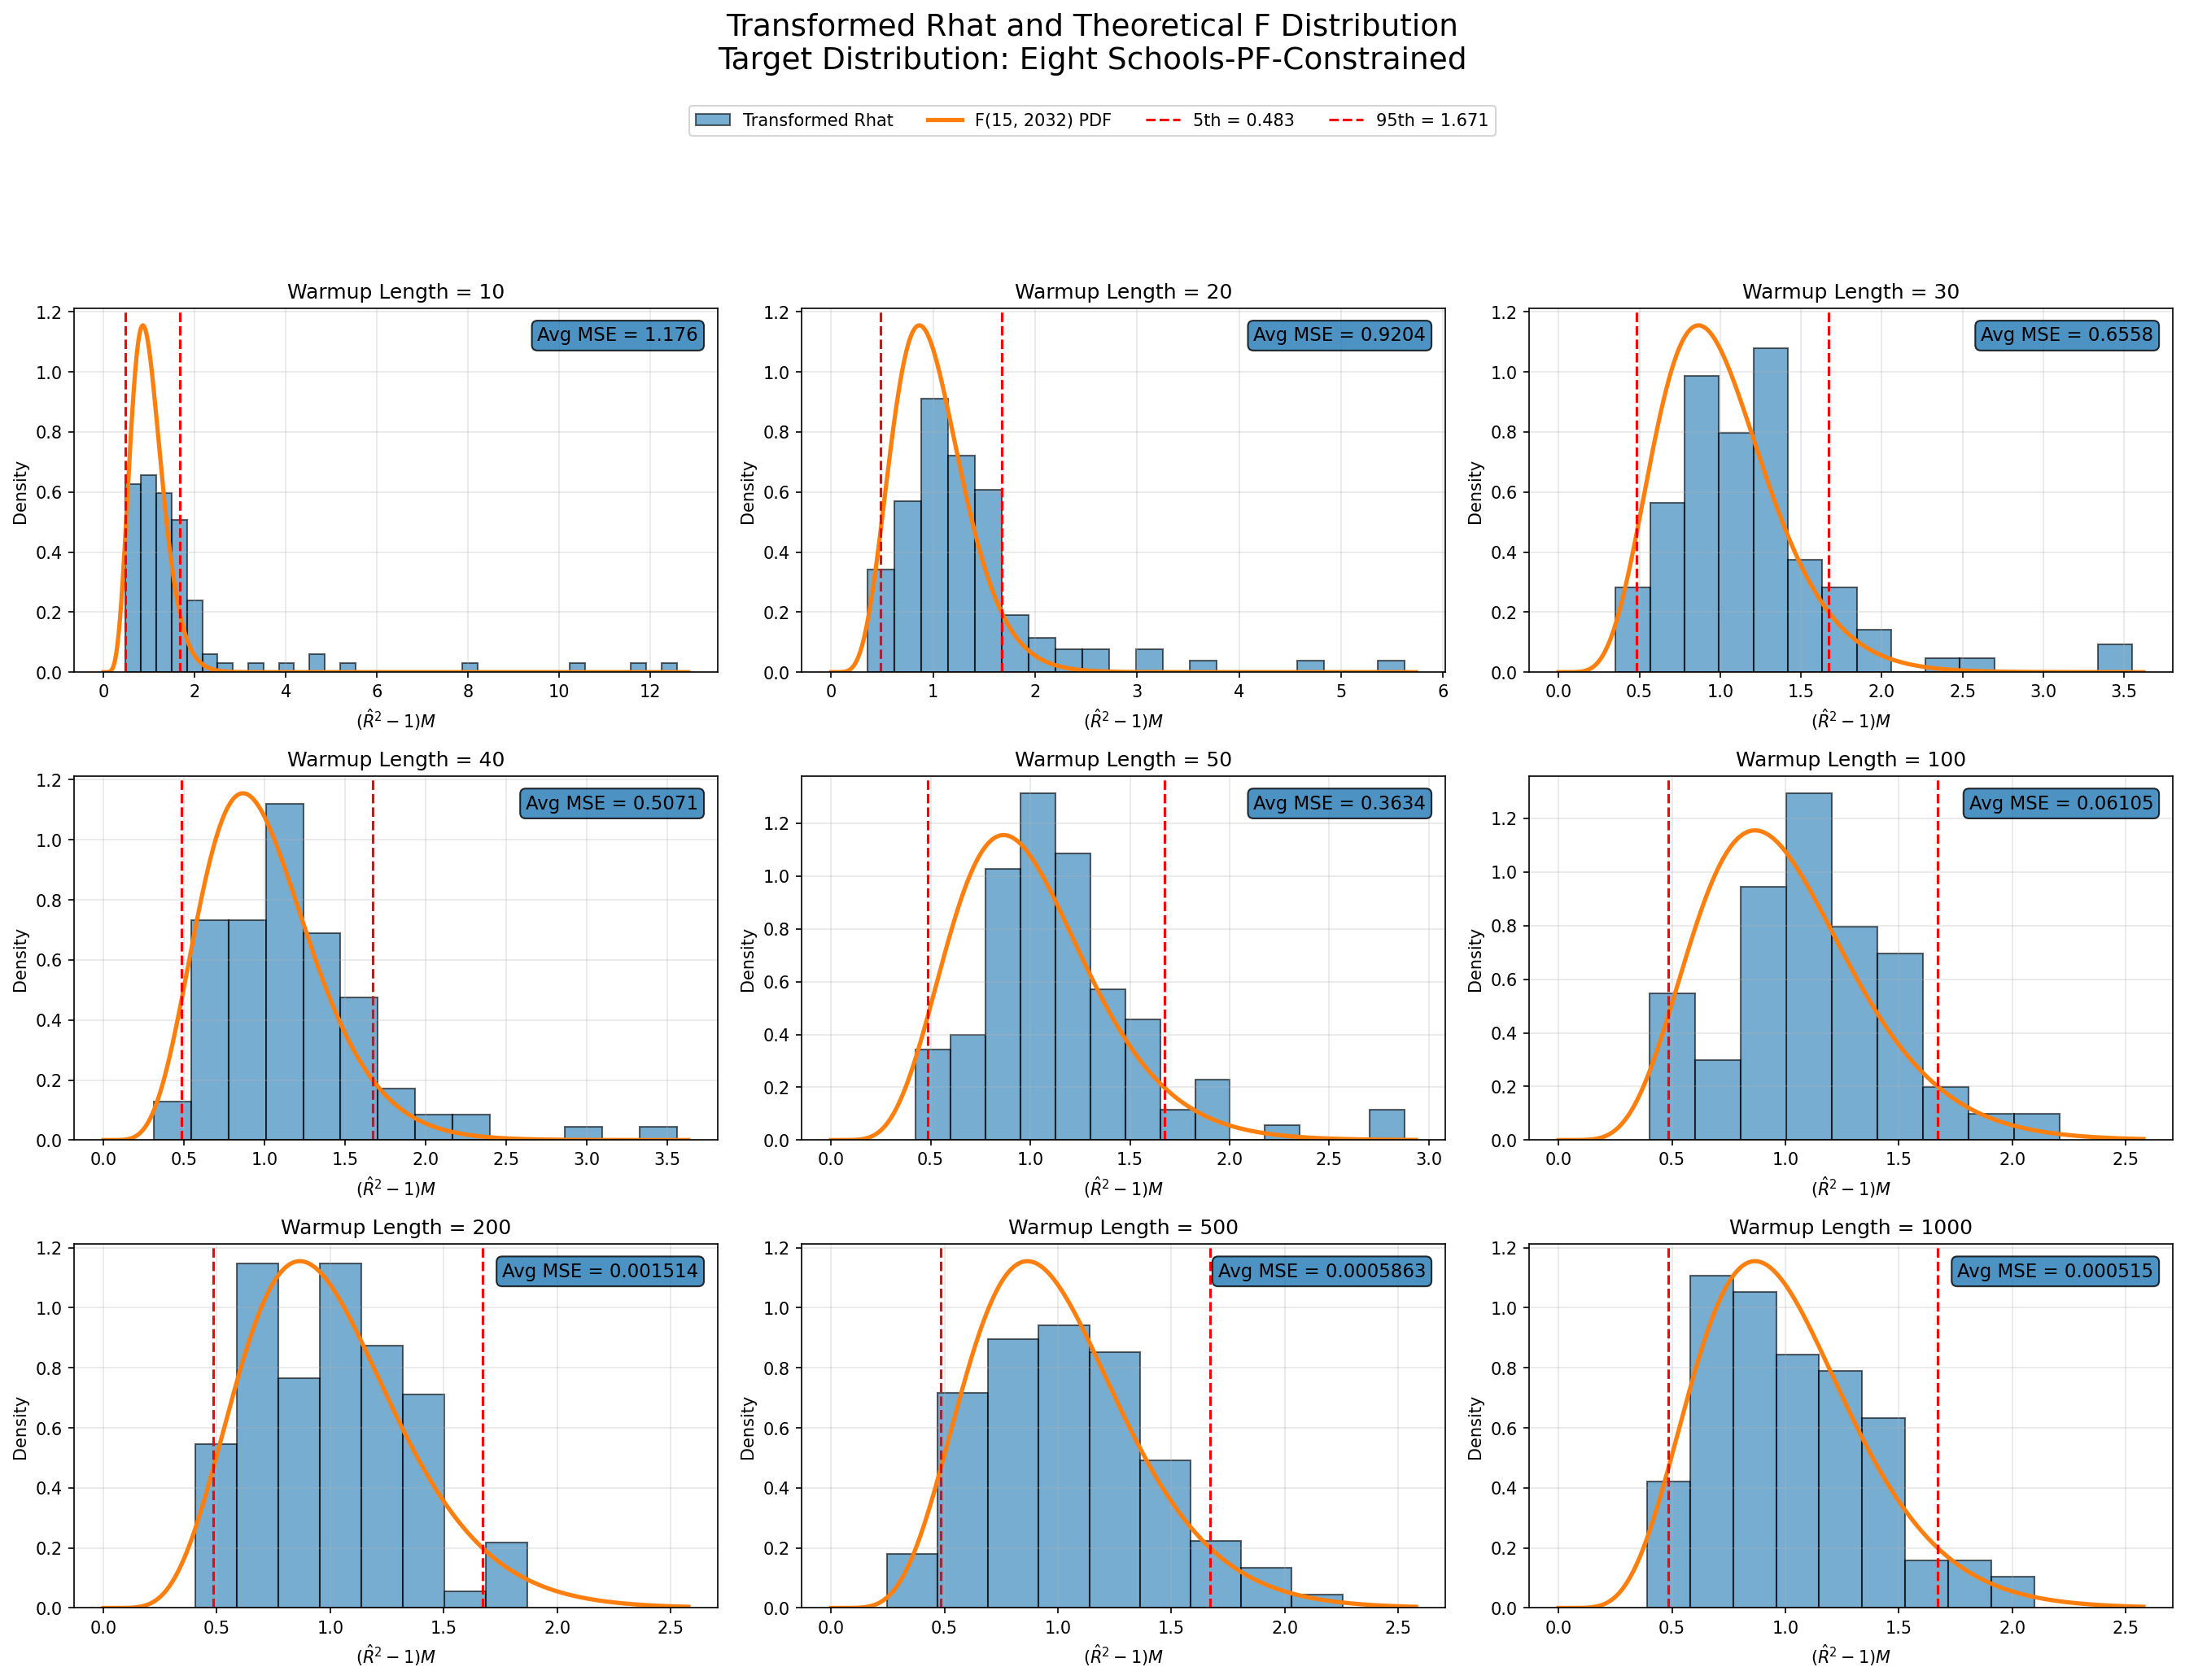

In [ ]:
plot_transformed_rhat_with_f(
    School_pf_R_Hat_c_df,
    "Eight Schools-PF-Constrained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

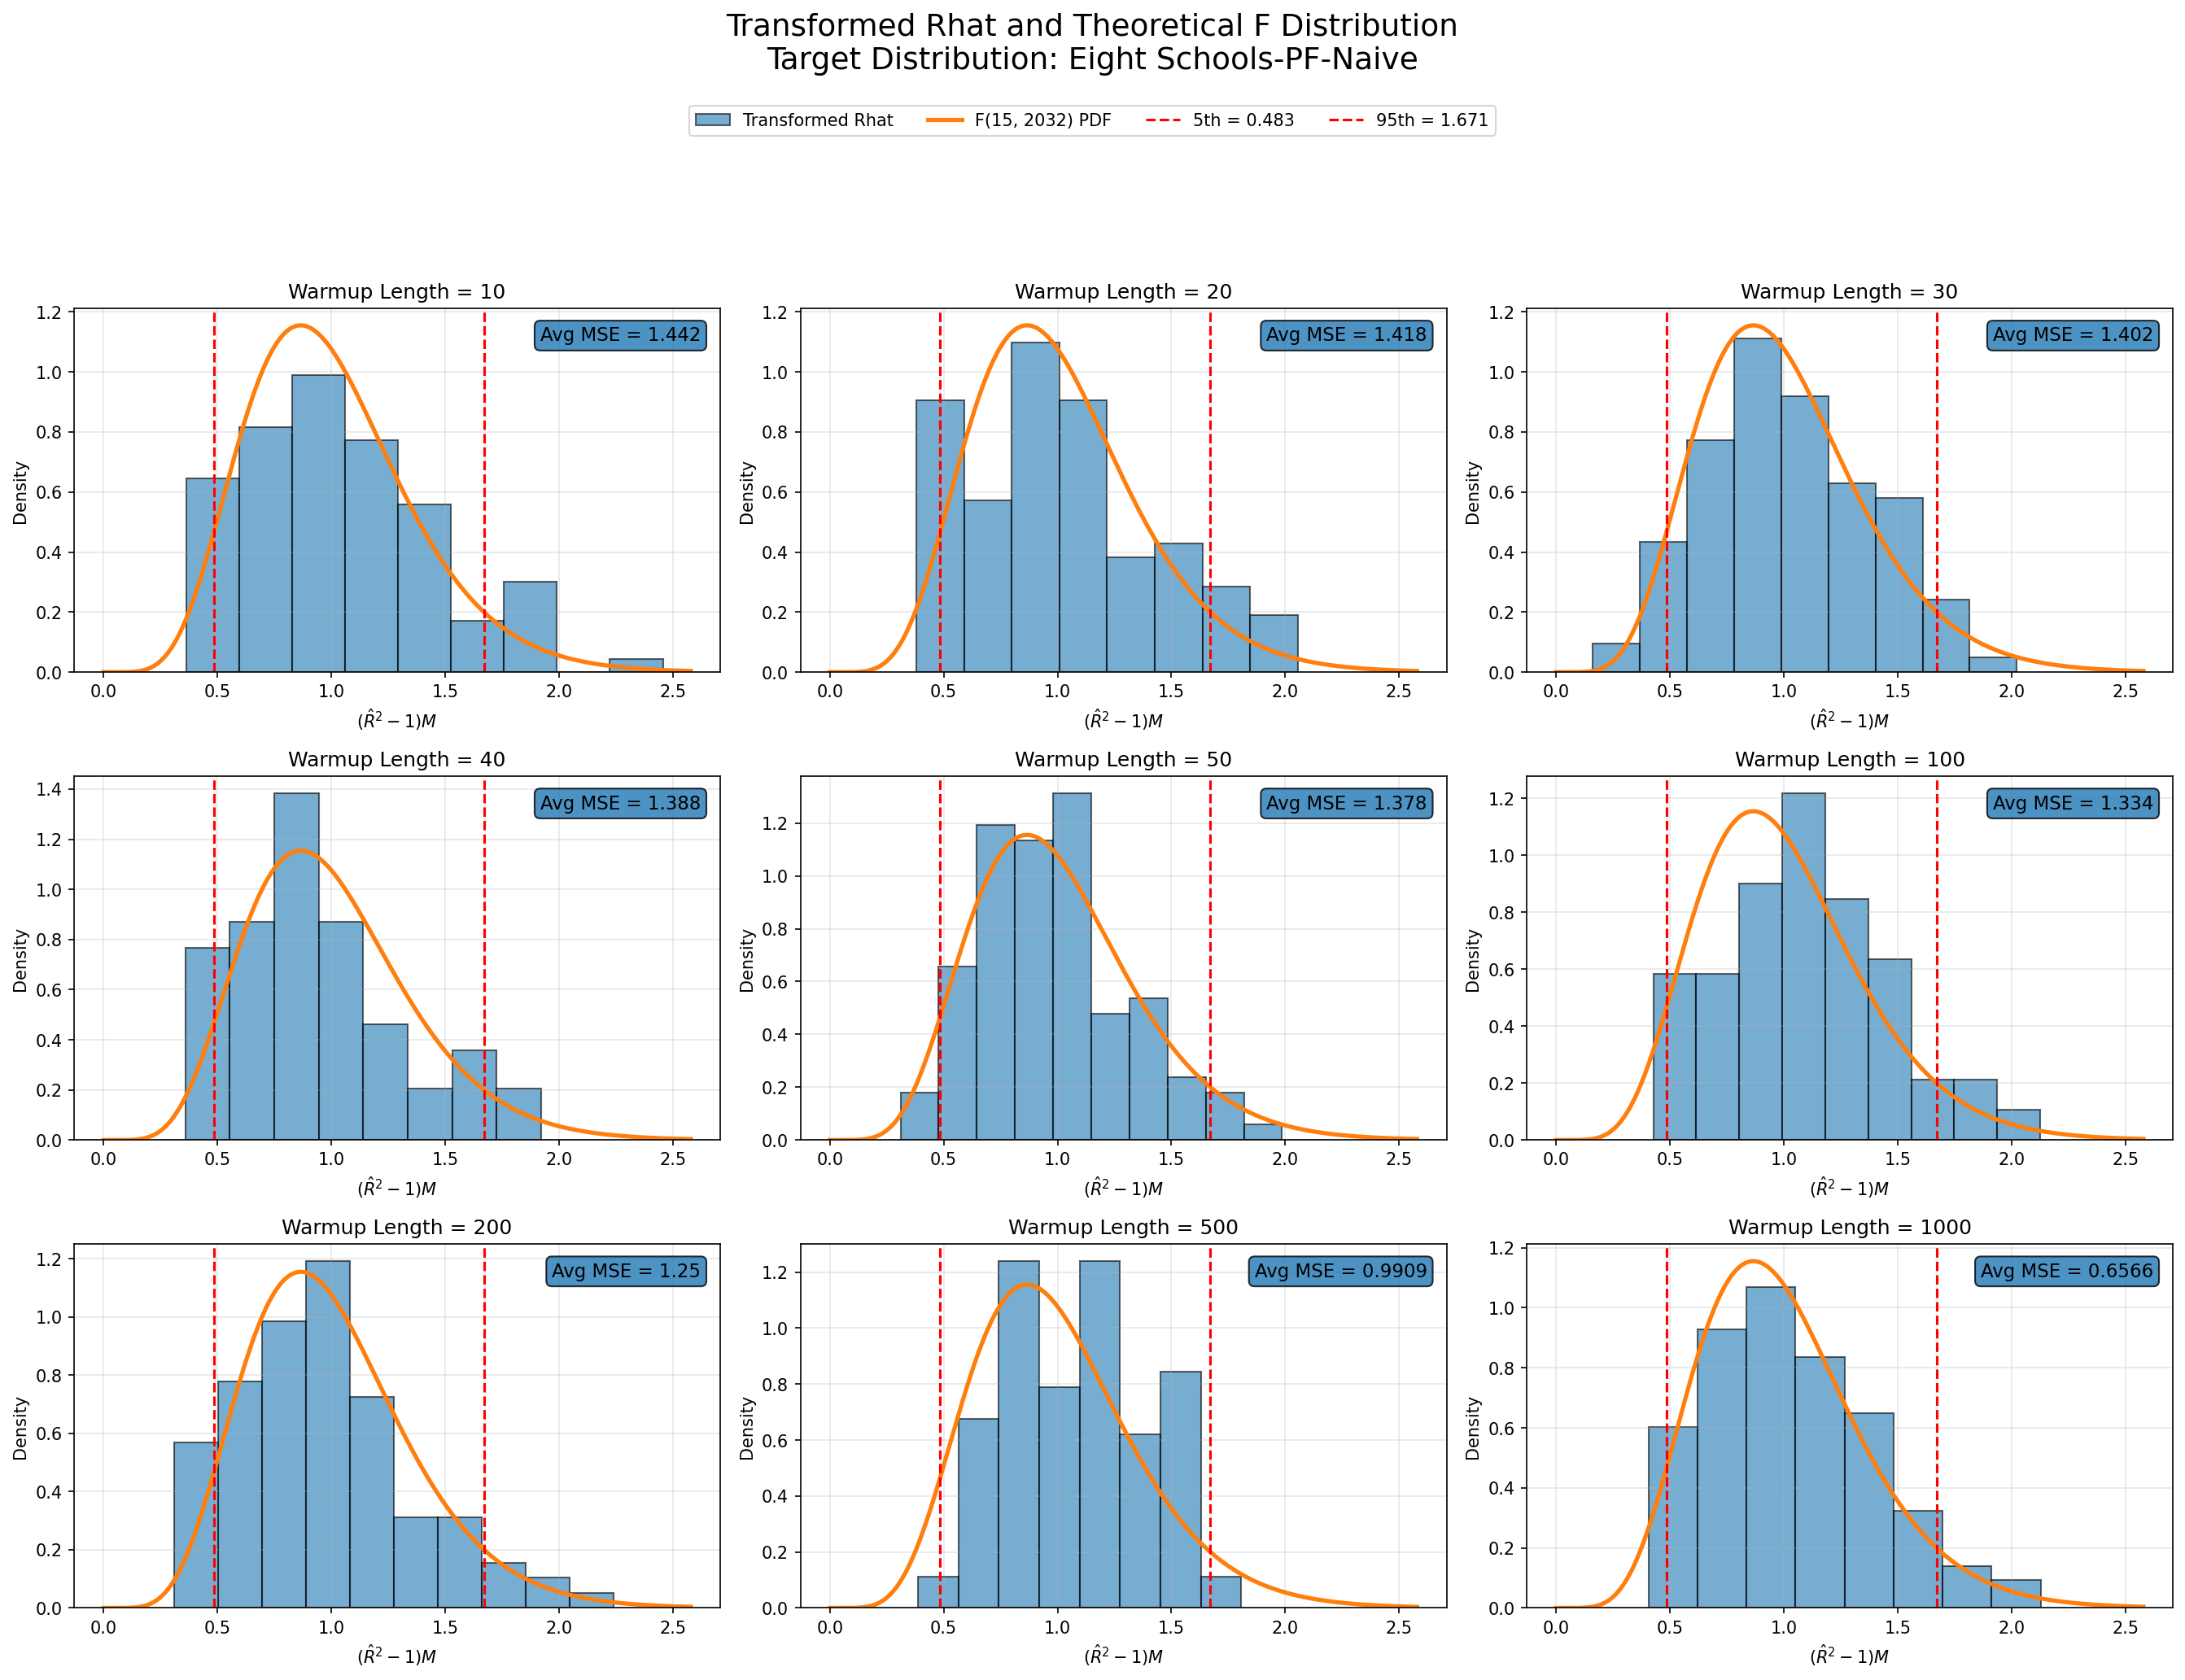

In [ ]:
plot_transformed_rhat_with_f(
    School_pf_R_Hat_n_df,
    "Eight Schools-PF-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

In [ ]:
School_bjx_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_constrained.pkl"
School_bjx_R_Hat_c_df = pd.read_pickle(School_bjx_R_hat_c_path)

School_bjx_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/BlackJAX_pkl_files/School_R_Hat_naive.pkl"
School_bjx_R_Hat_n_df = pd.read_pickle(School_bjx_R_hat_n_path)
print("BlackJAX implementation data Loaded!")

BlackJAX implementation data Loaded!


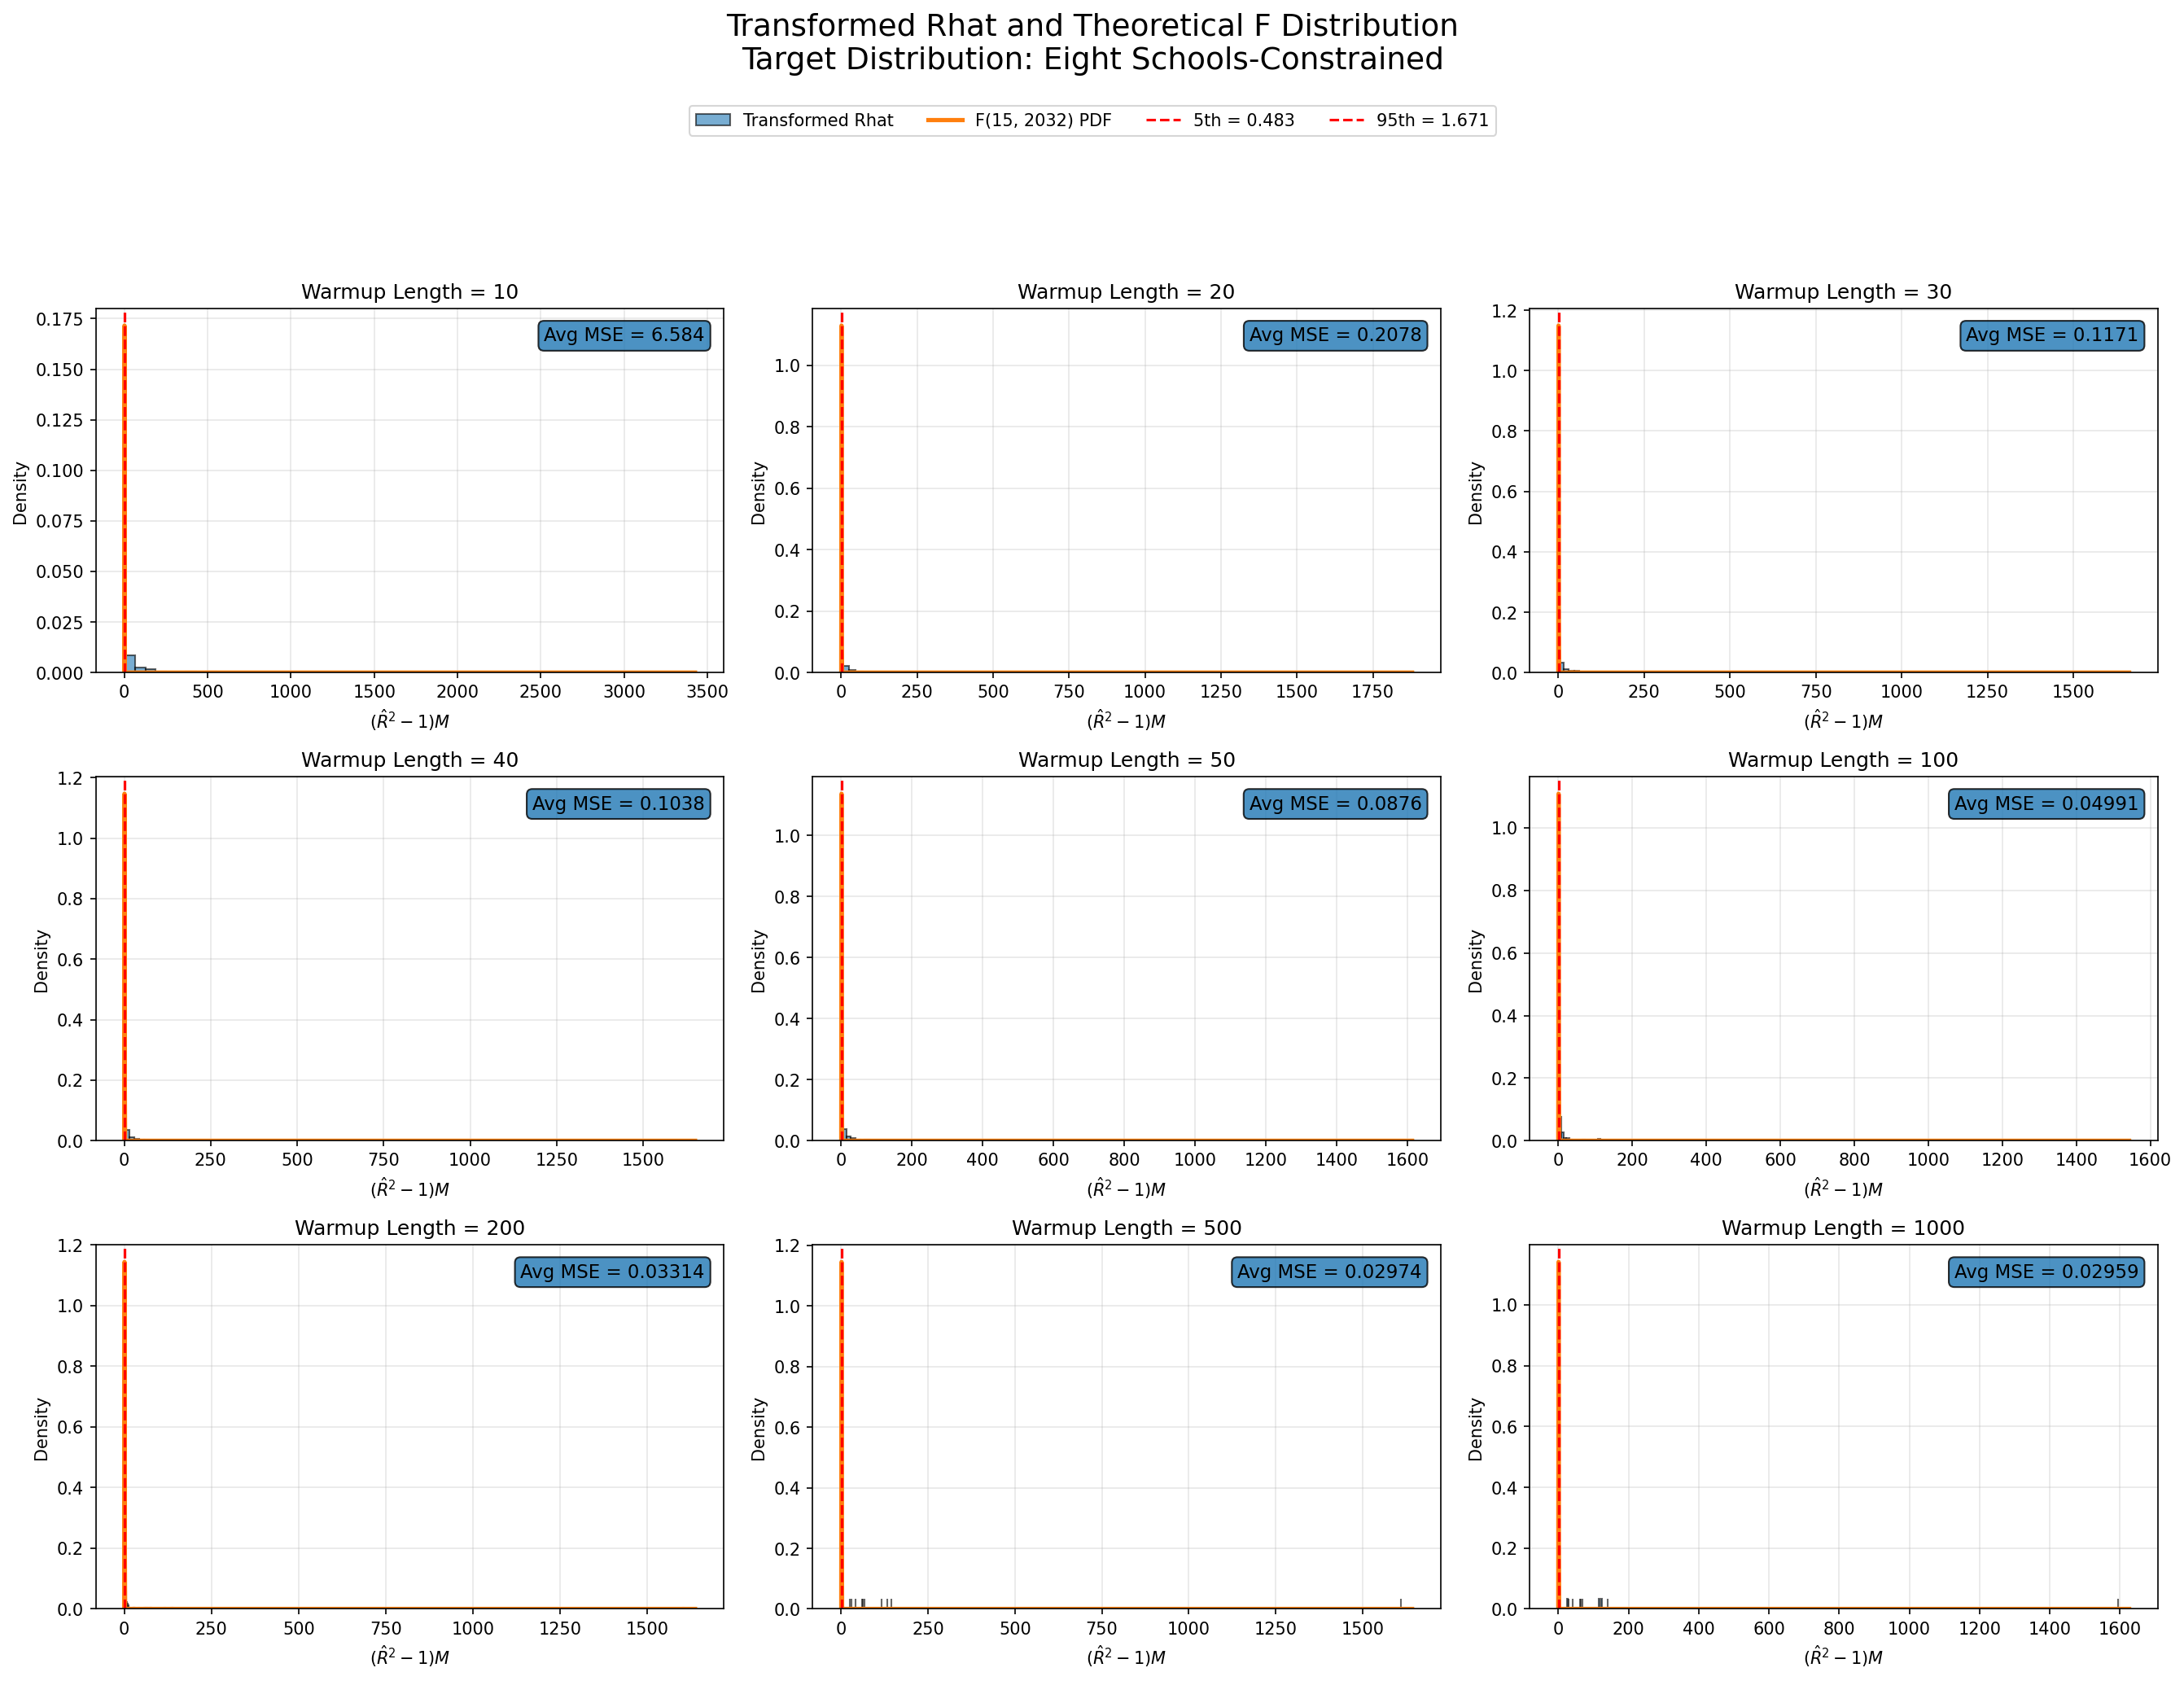

In [ ]:
plot_transformed_rhat_with_f(
    School_bjx_R_Hat_c_df,
    "Eight Schools-Constrained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

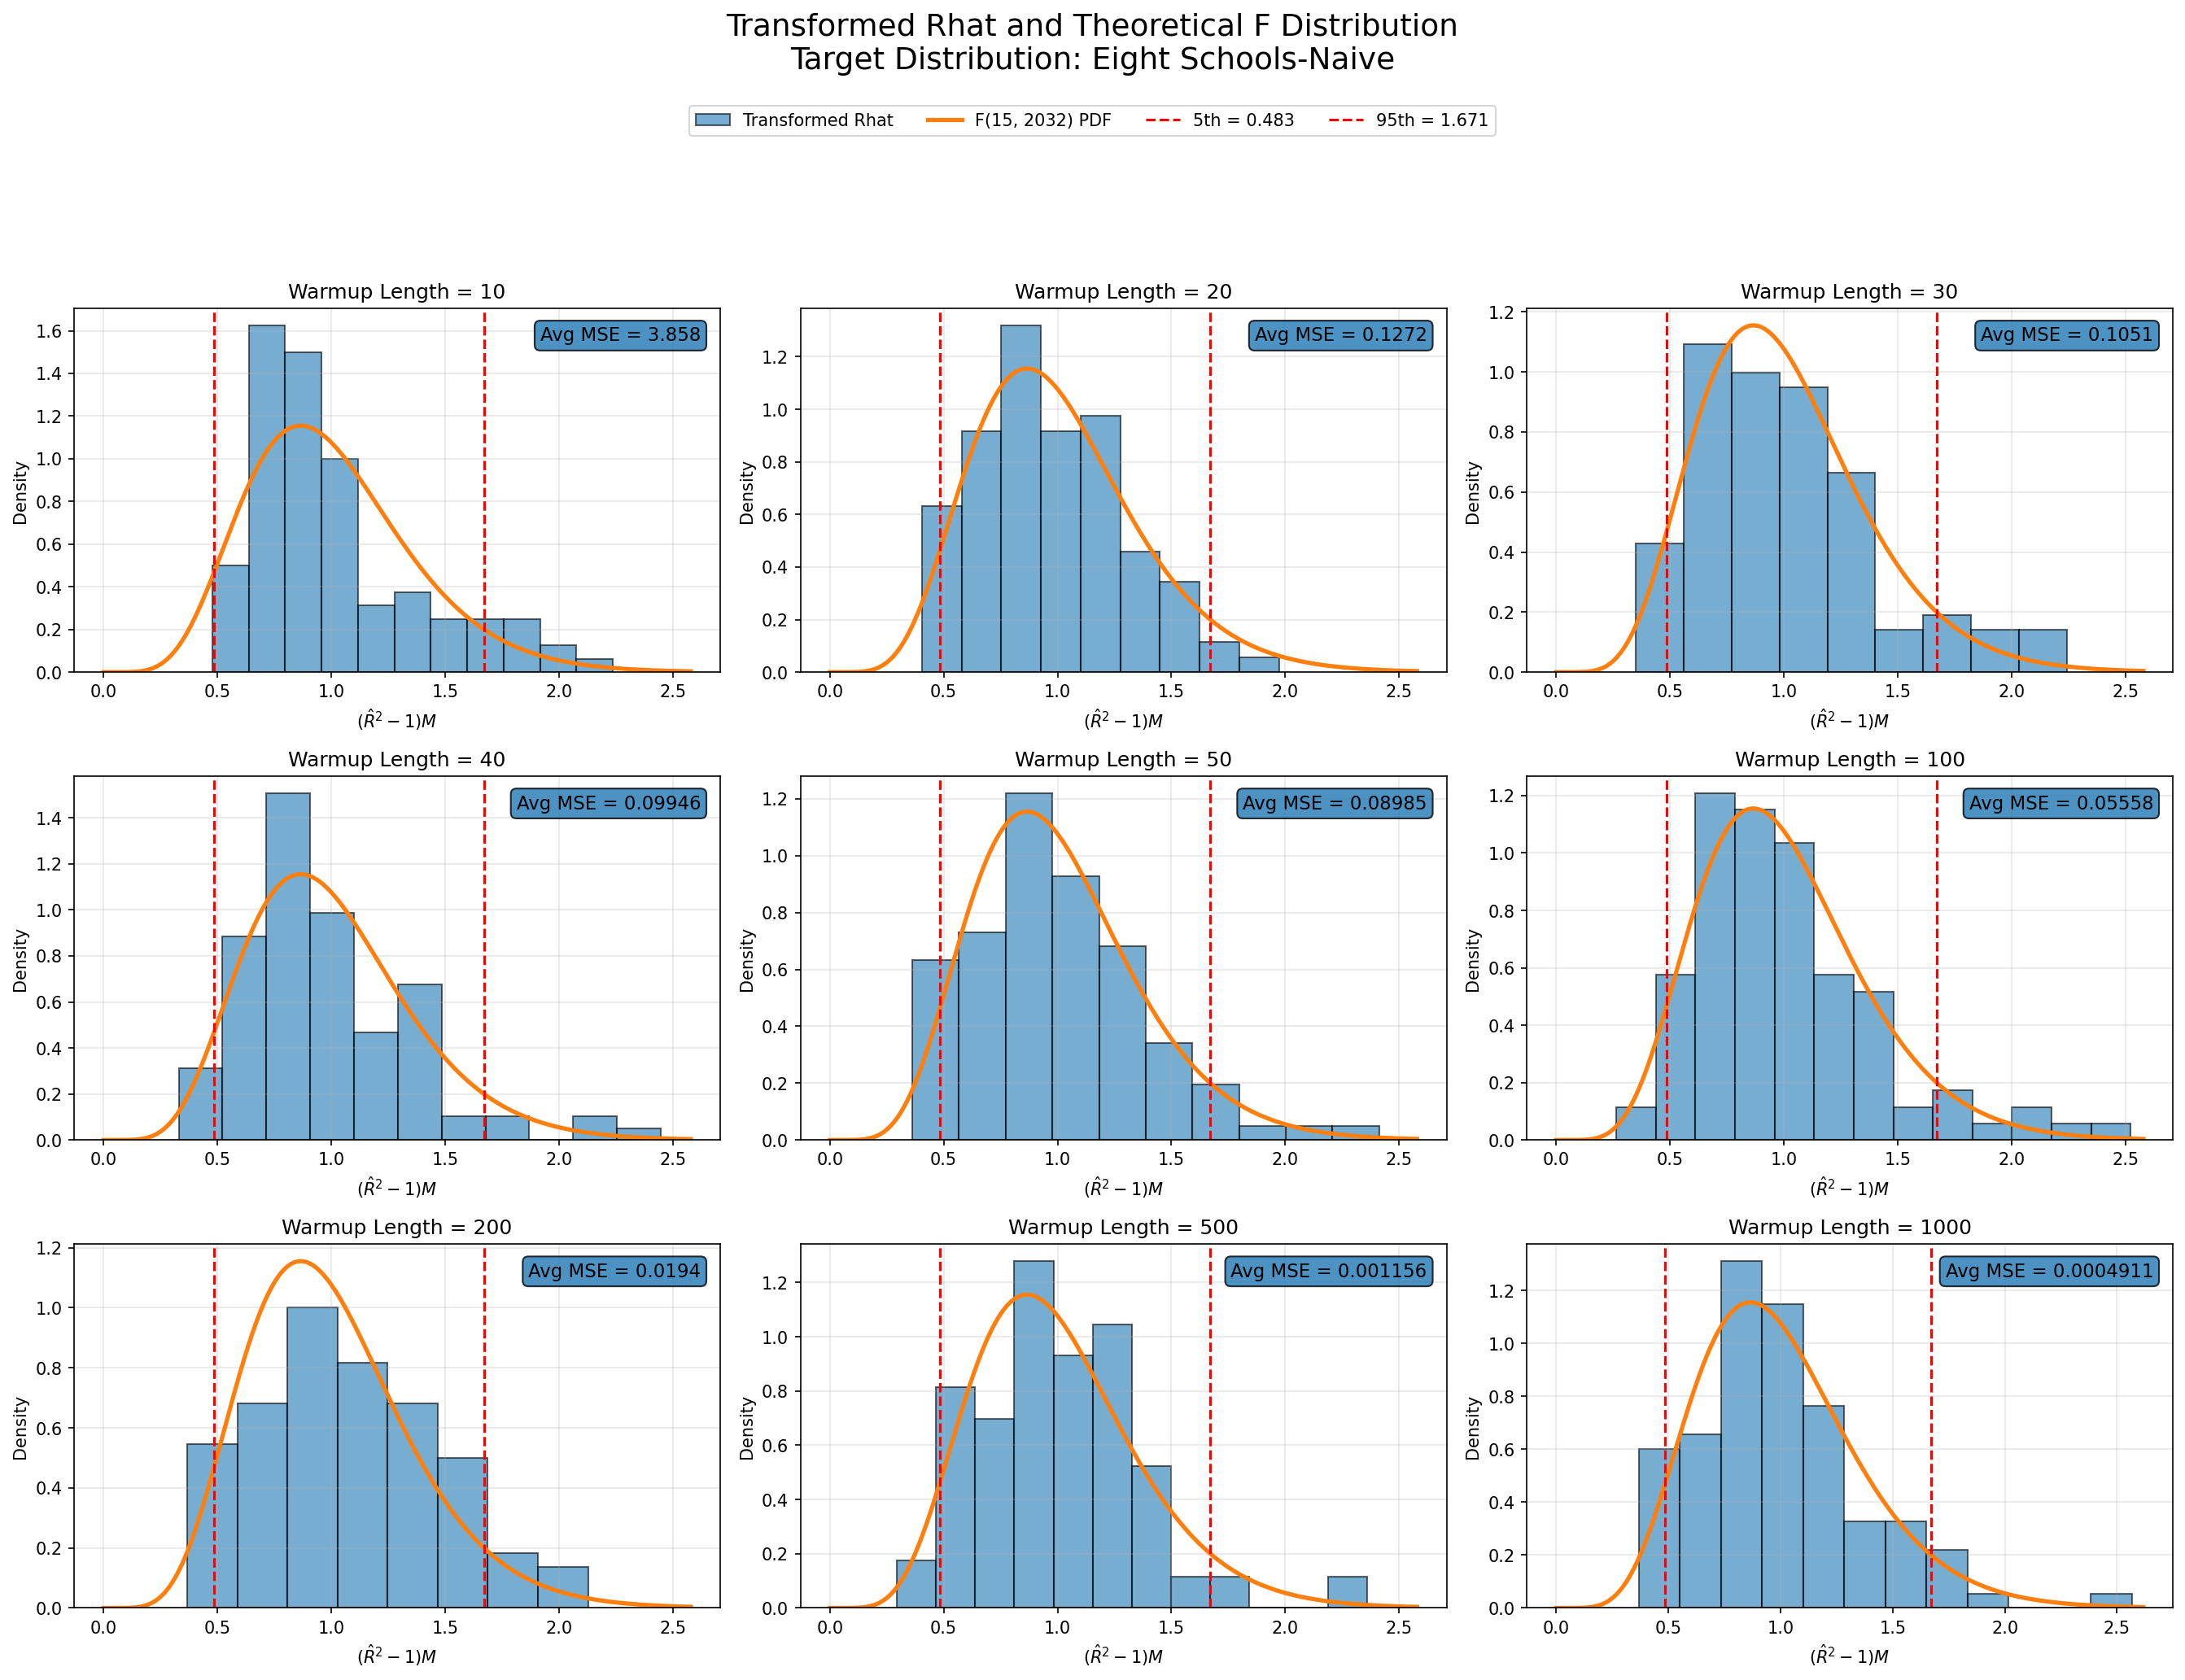

In [ ]:
plot_transformed_rhat_with_f(
    School_bjx_R_Hat_n_df,
    "Eight Schools-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

**Diagonal Experiment**

In [ ]:
# Diagonal Experiments:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_1_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

R_Hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_1_1_Rhat_n.pkl"
R_Hat_n_df = pd.read_pickle(R_Hat_n_path)

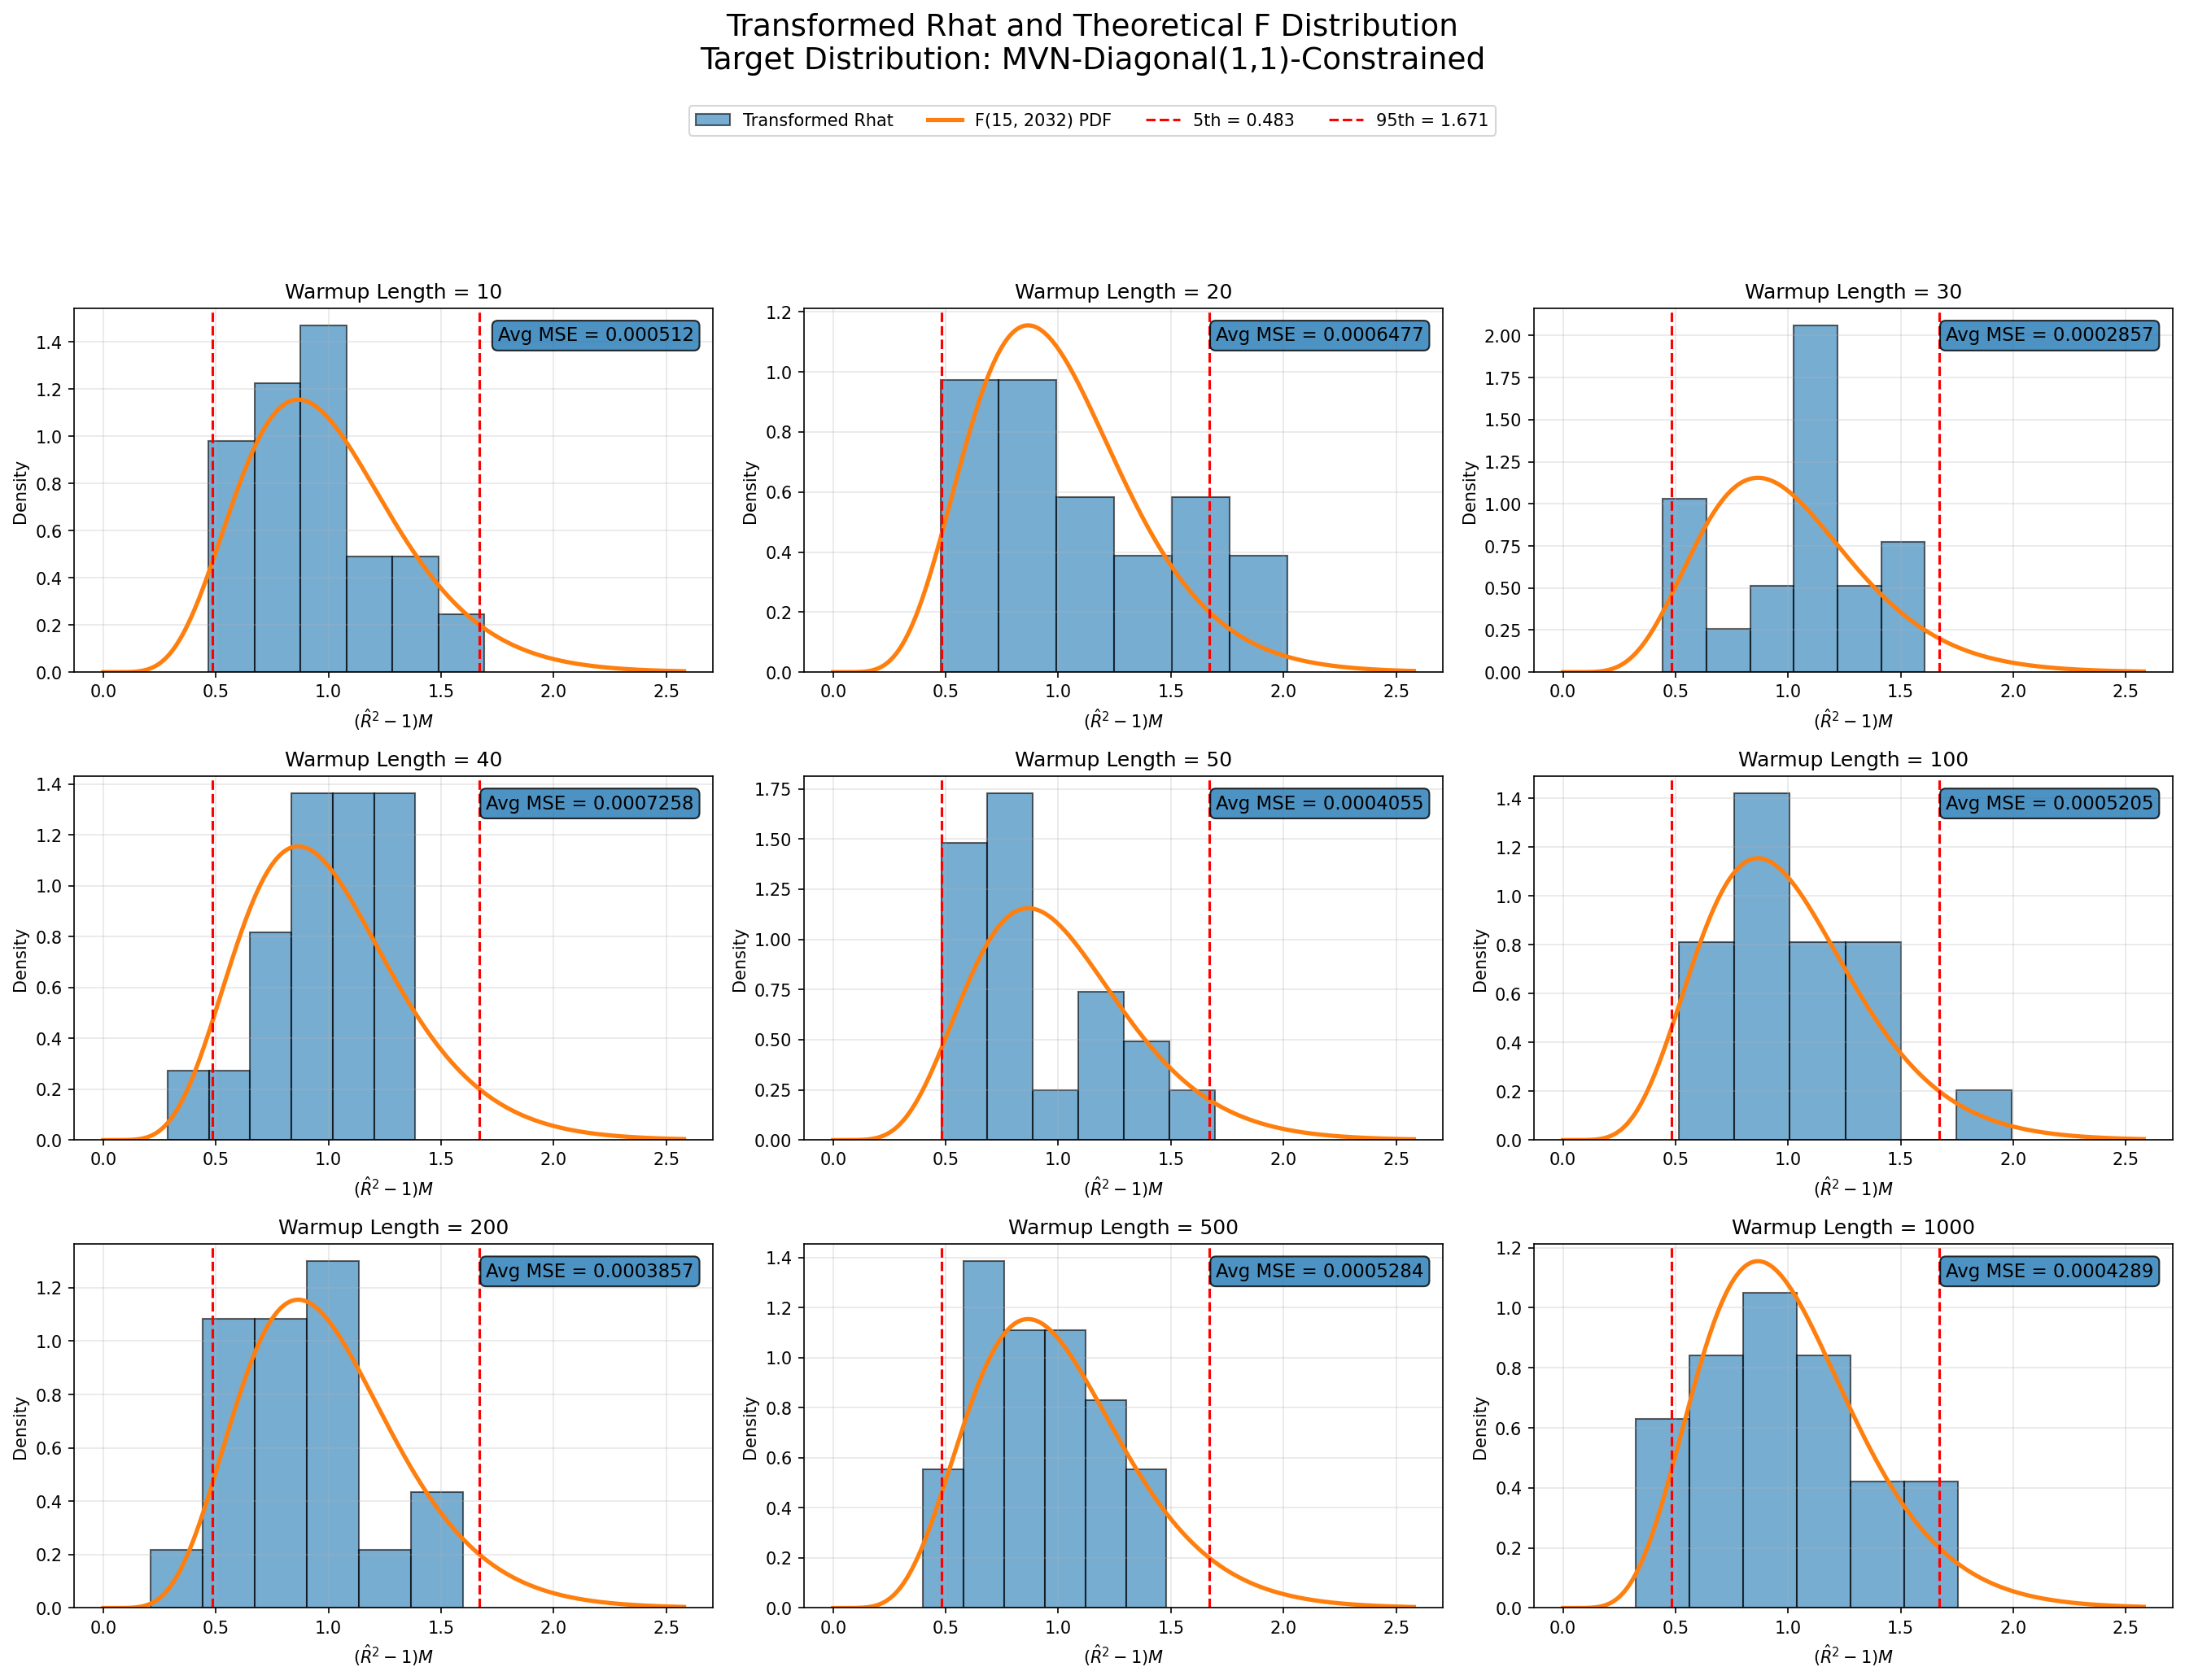

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_c_df,
    "MVN-Diagonal(1,1)-Constrained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

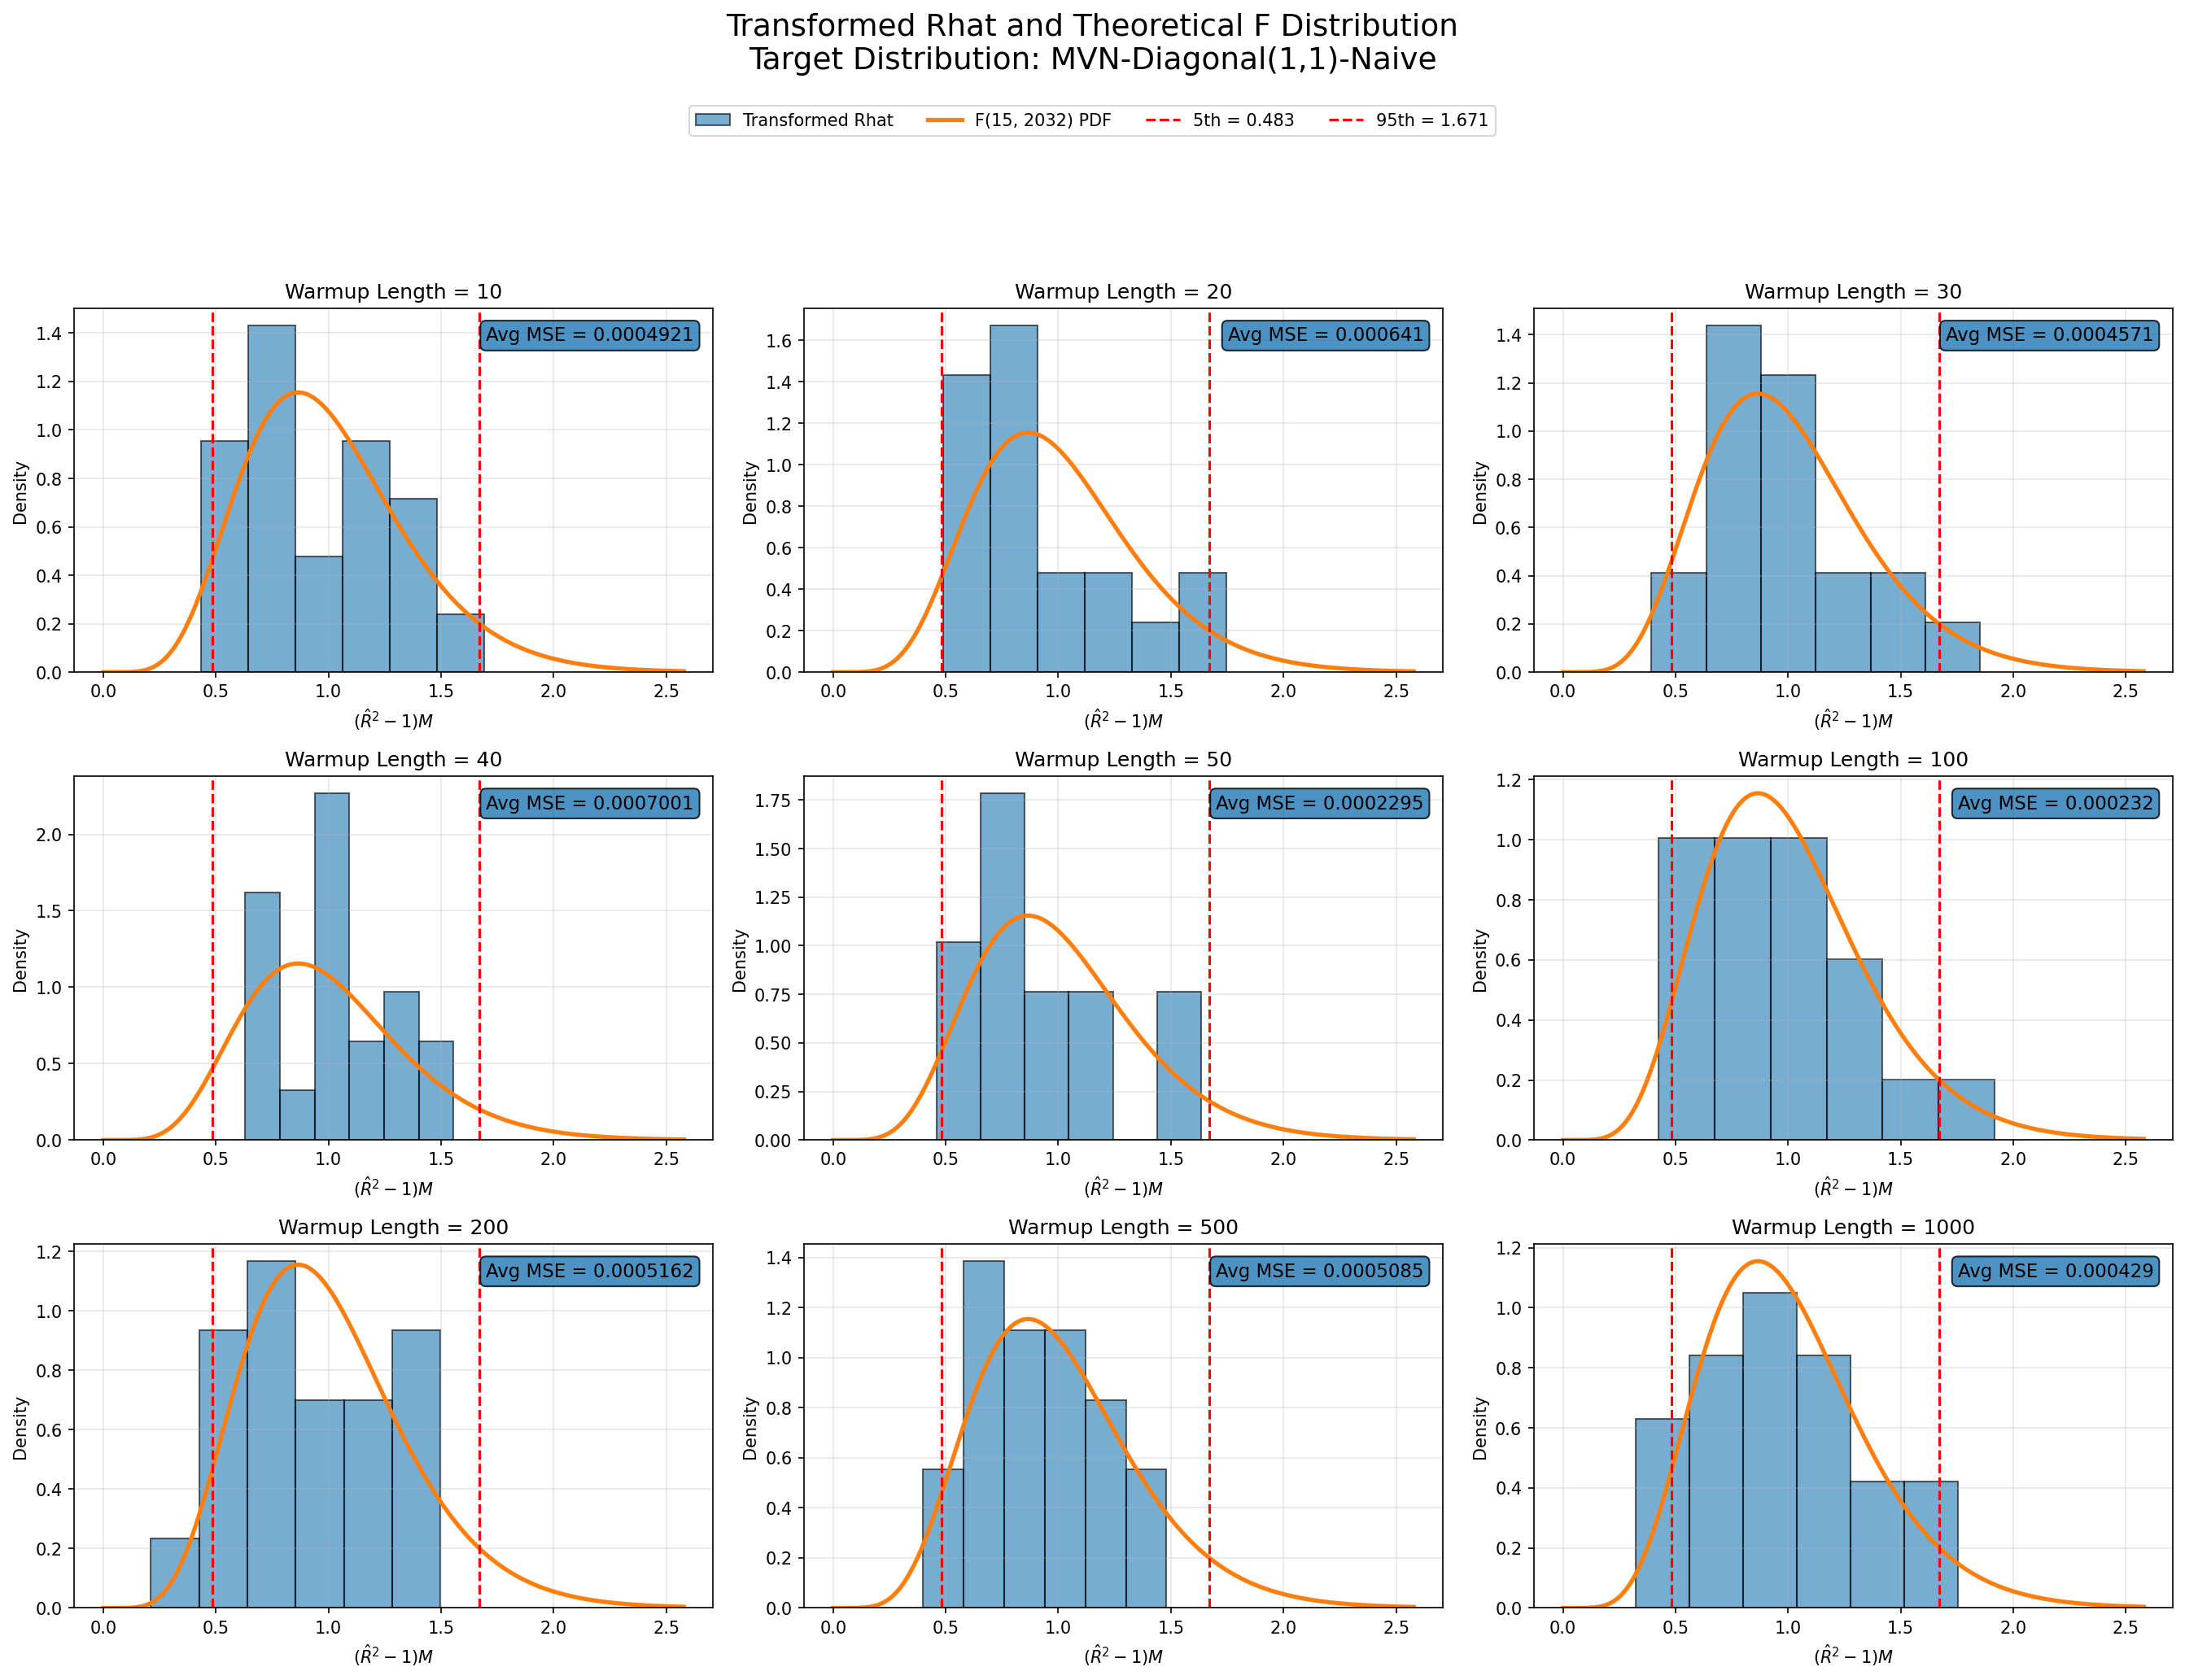

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_n_df,
    "MVN-Diagonal(1,1)-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

In [ ]:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_10_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

R_Hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_10_1_Rhat_n.pkl"
R_Hat_n_df = pd.read_pickle(R_Hat_n_path)

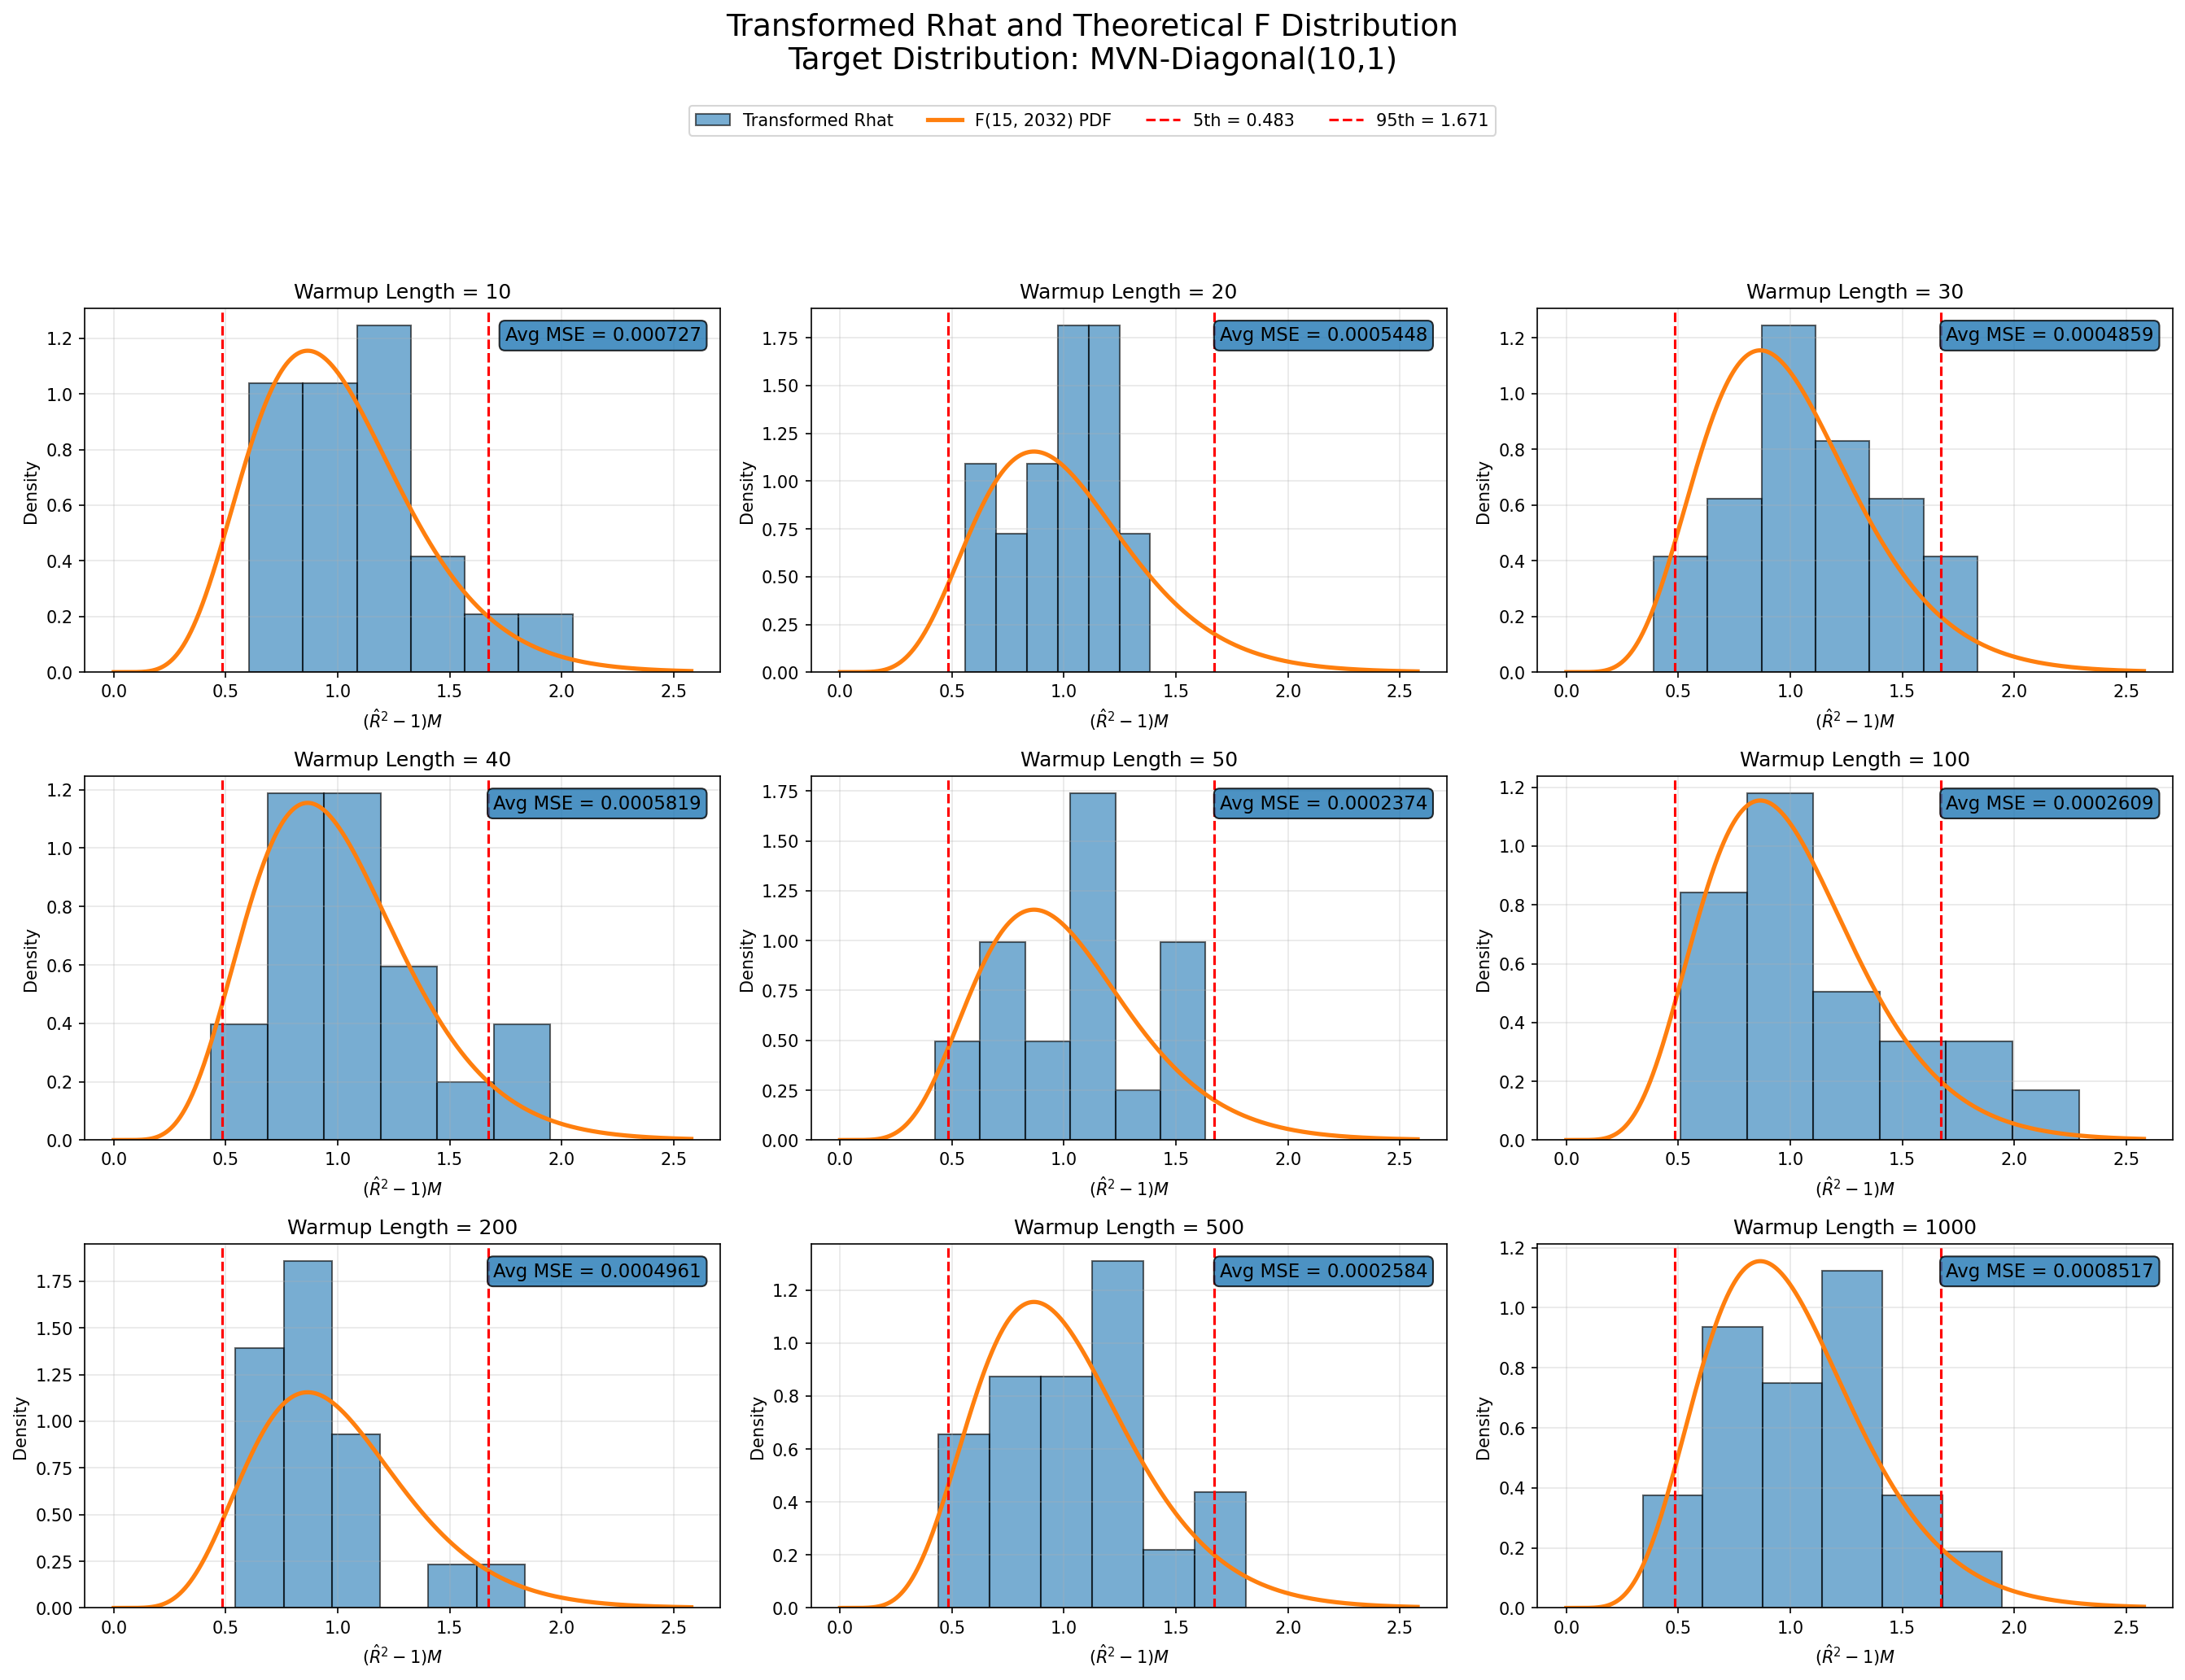

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_c_df,
    "MVN-Diagonal(10,1)-Constrained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

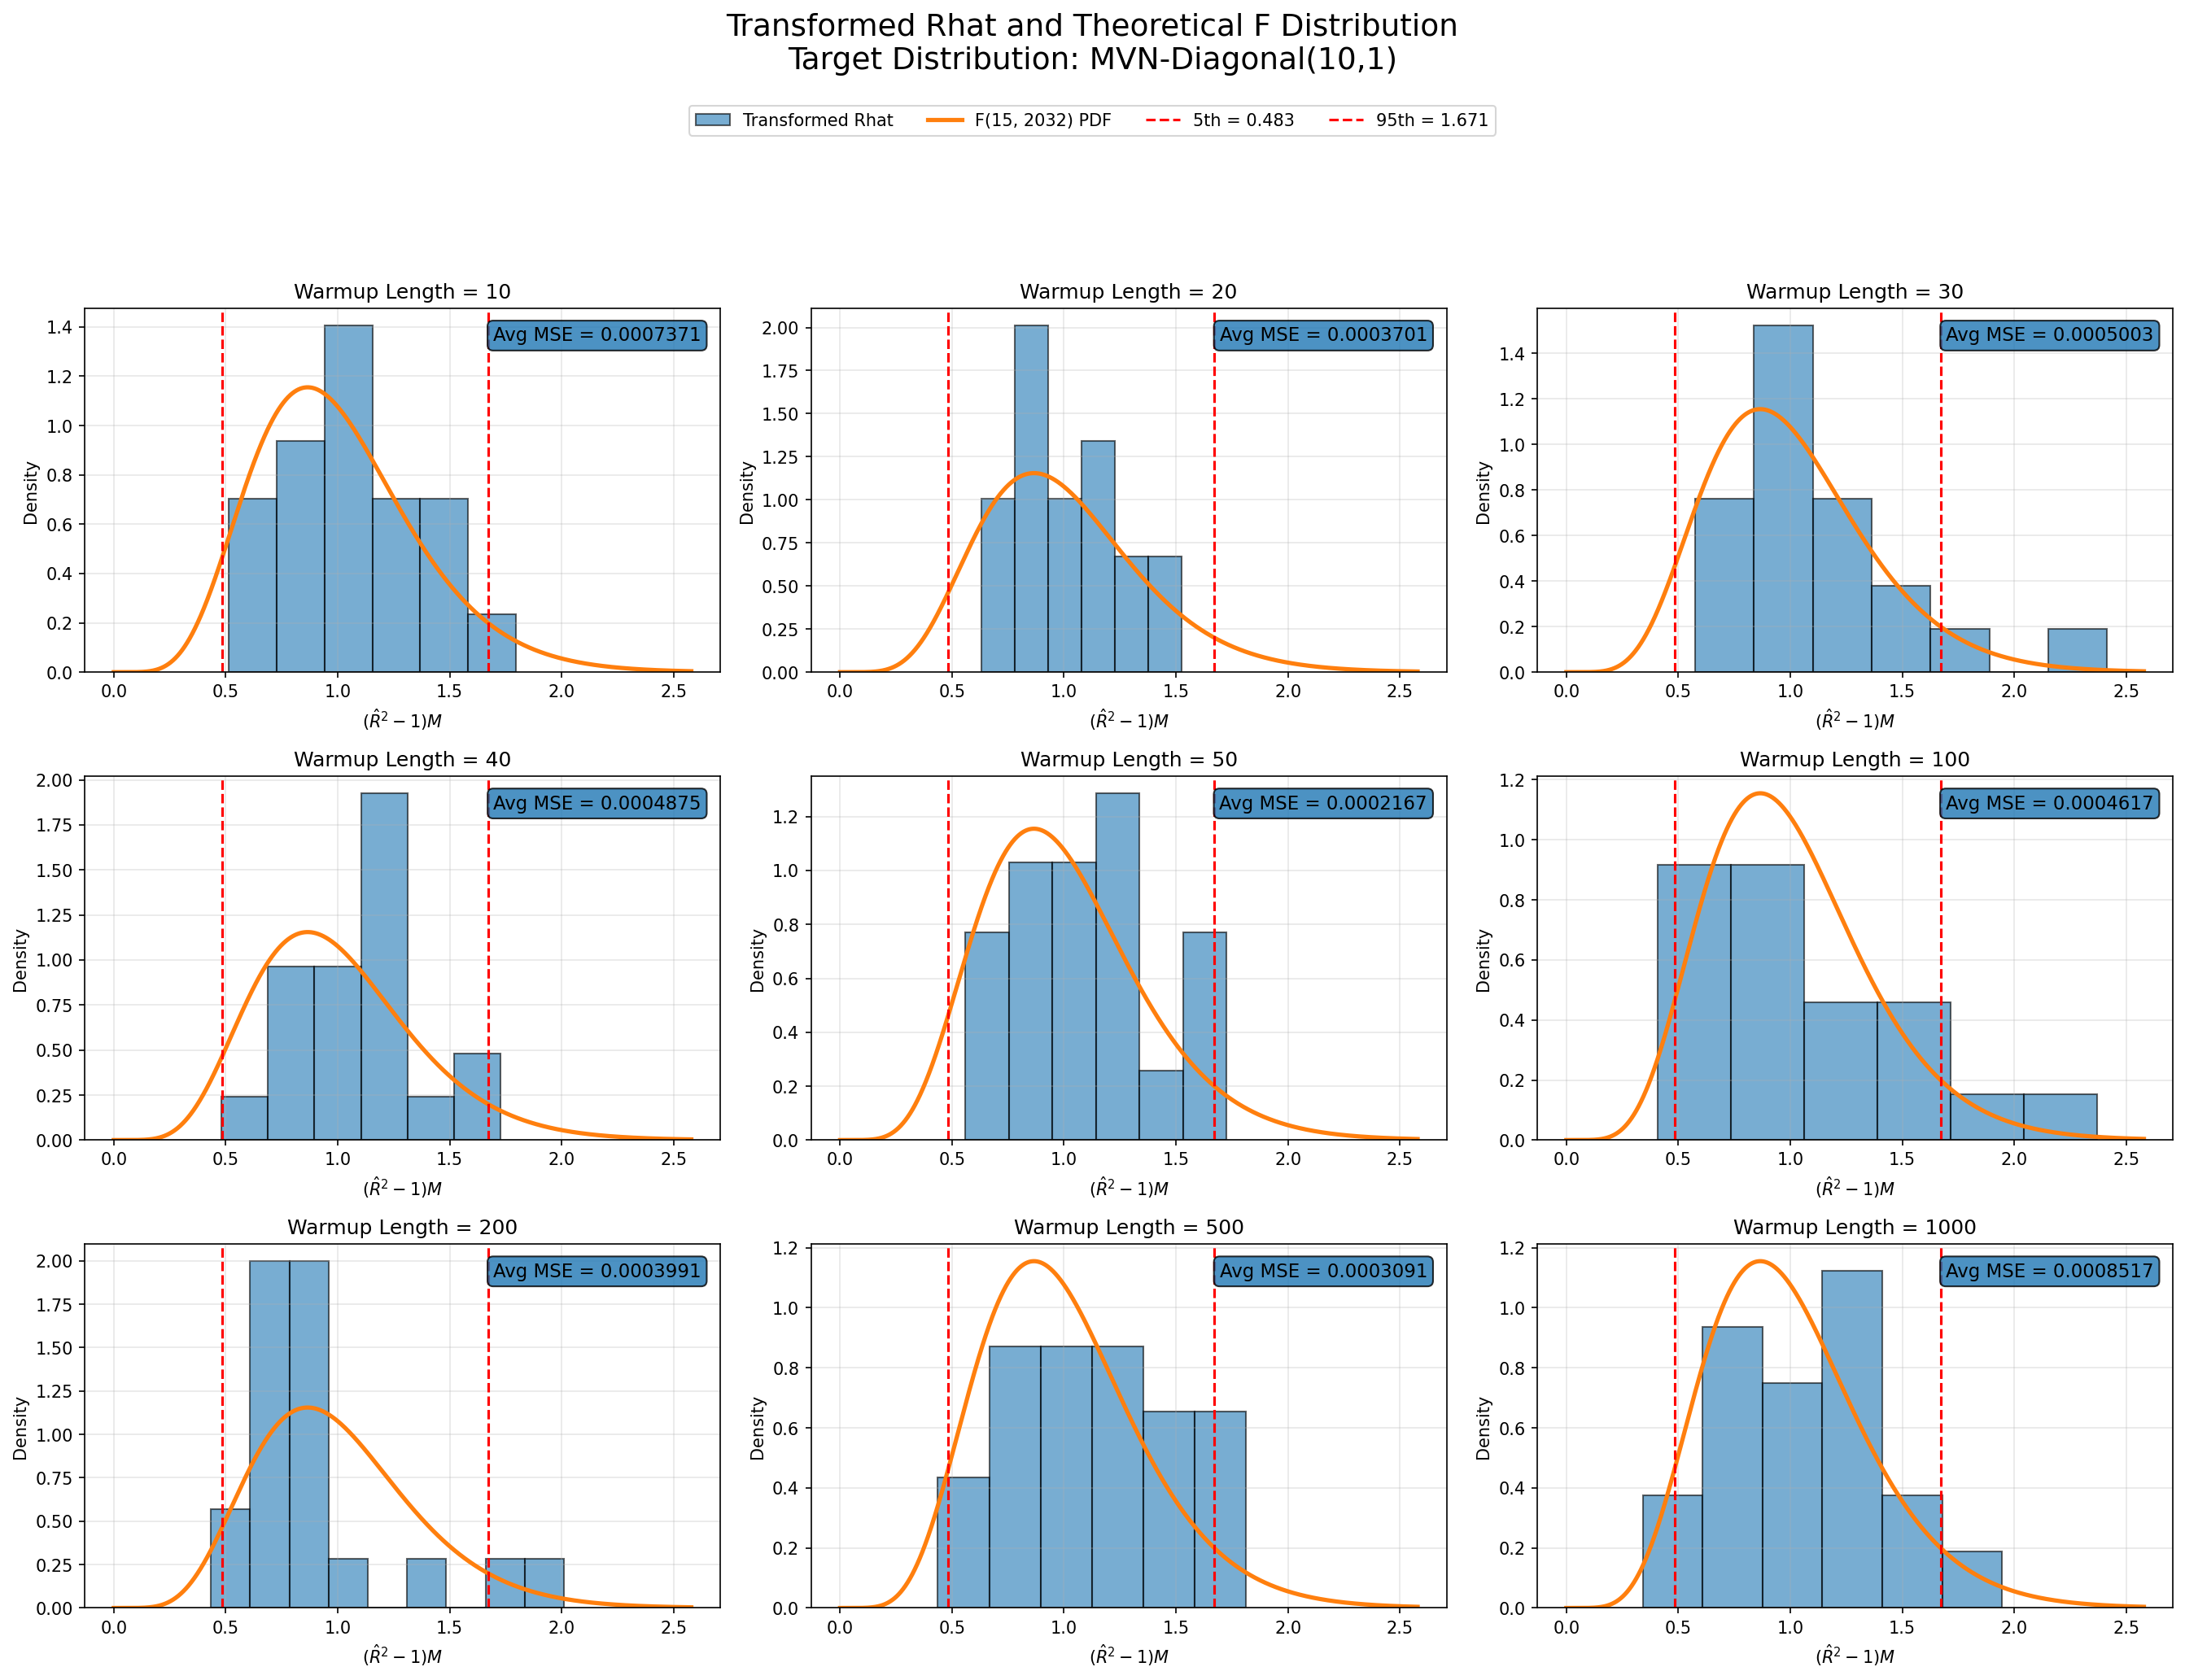

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_n_df,
    "MVN-Diagonal(10,1)-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

In [ ]:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_100_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

R_Hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_100_1_Rhat_n.pkl"
R_Hat_n_df = pd.read_pickle(R_Hat_n_path)

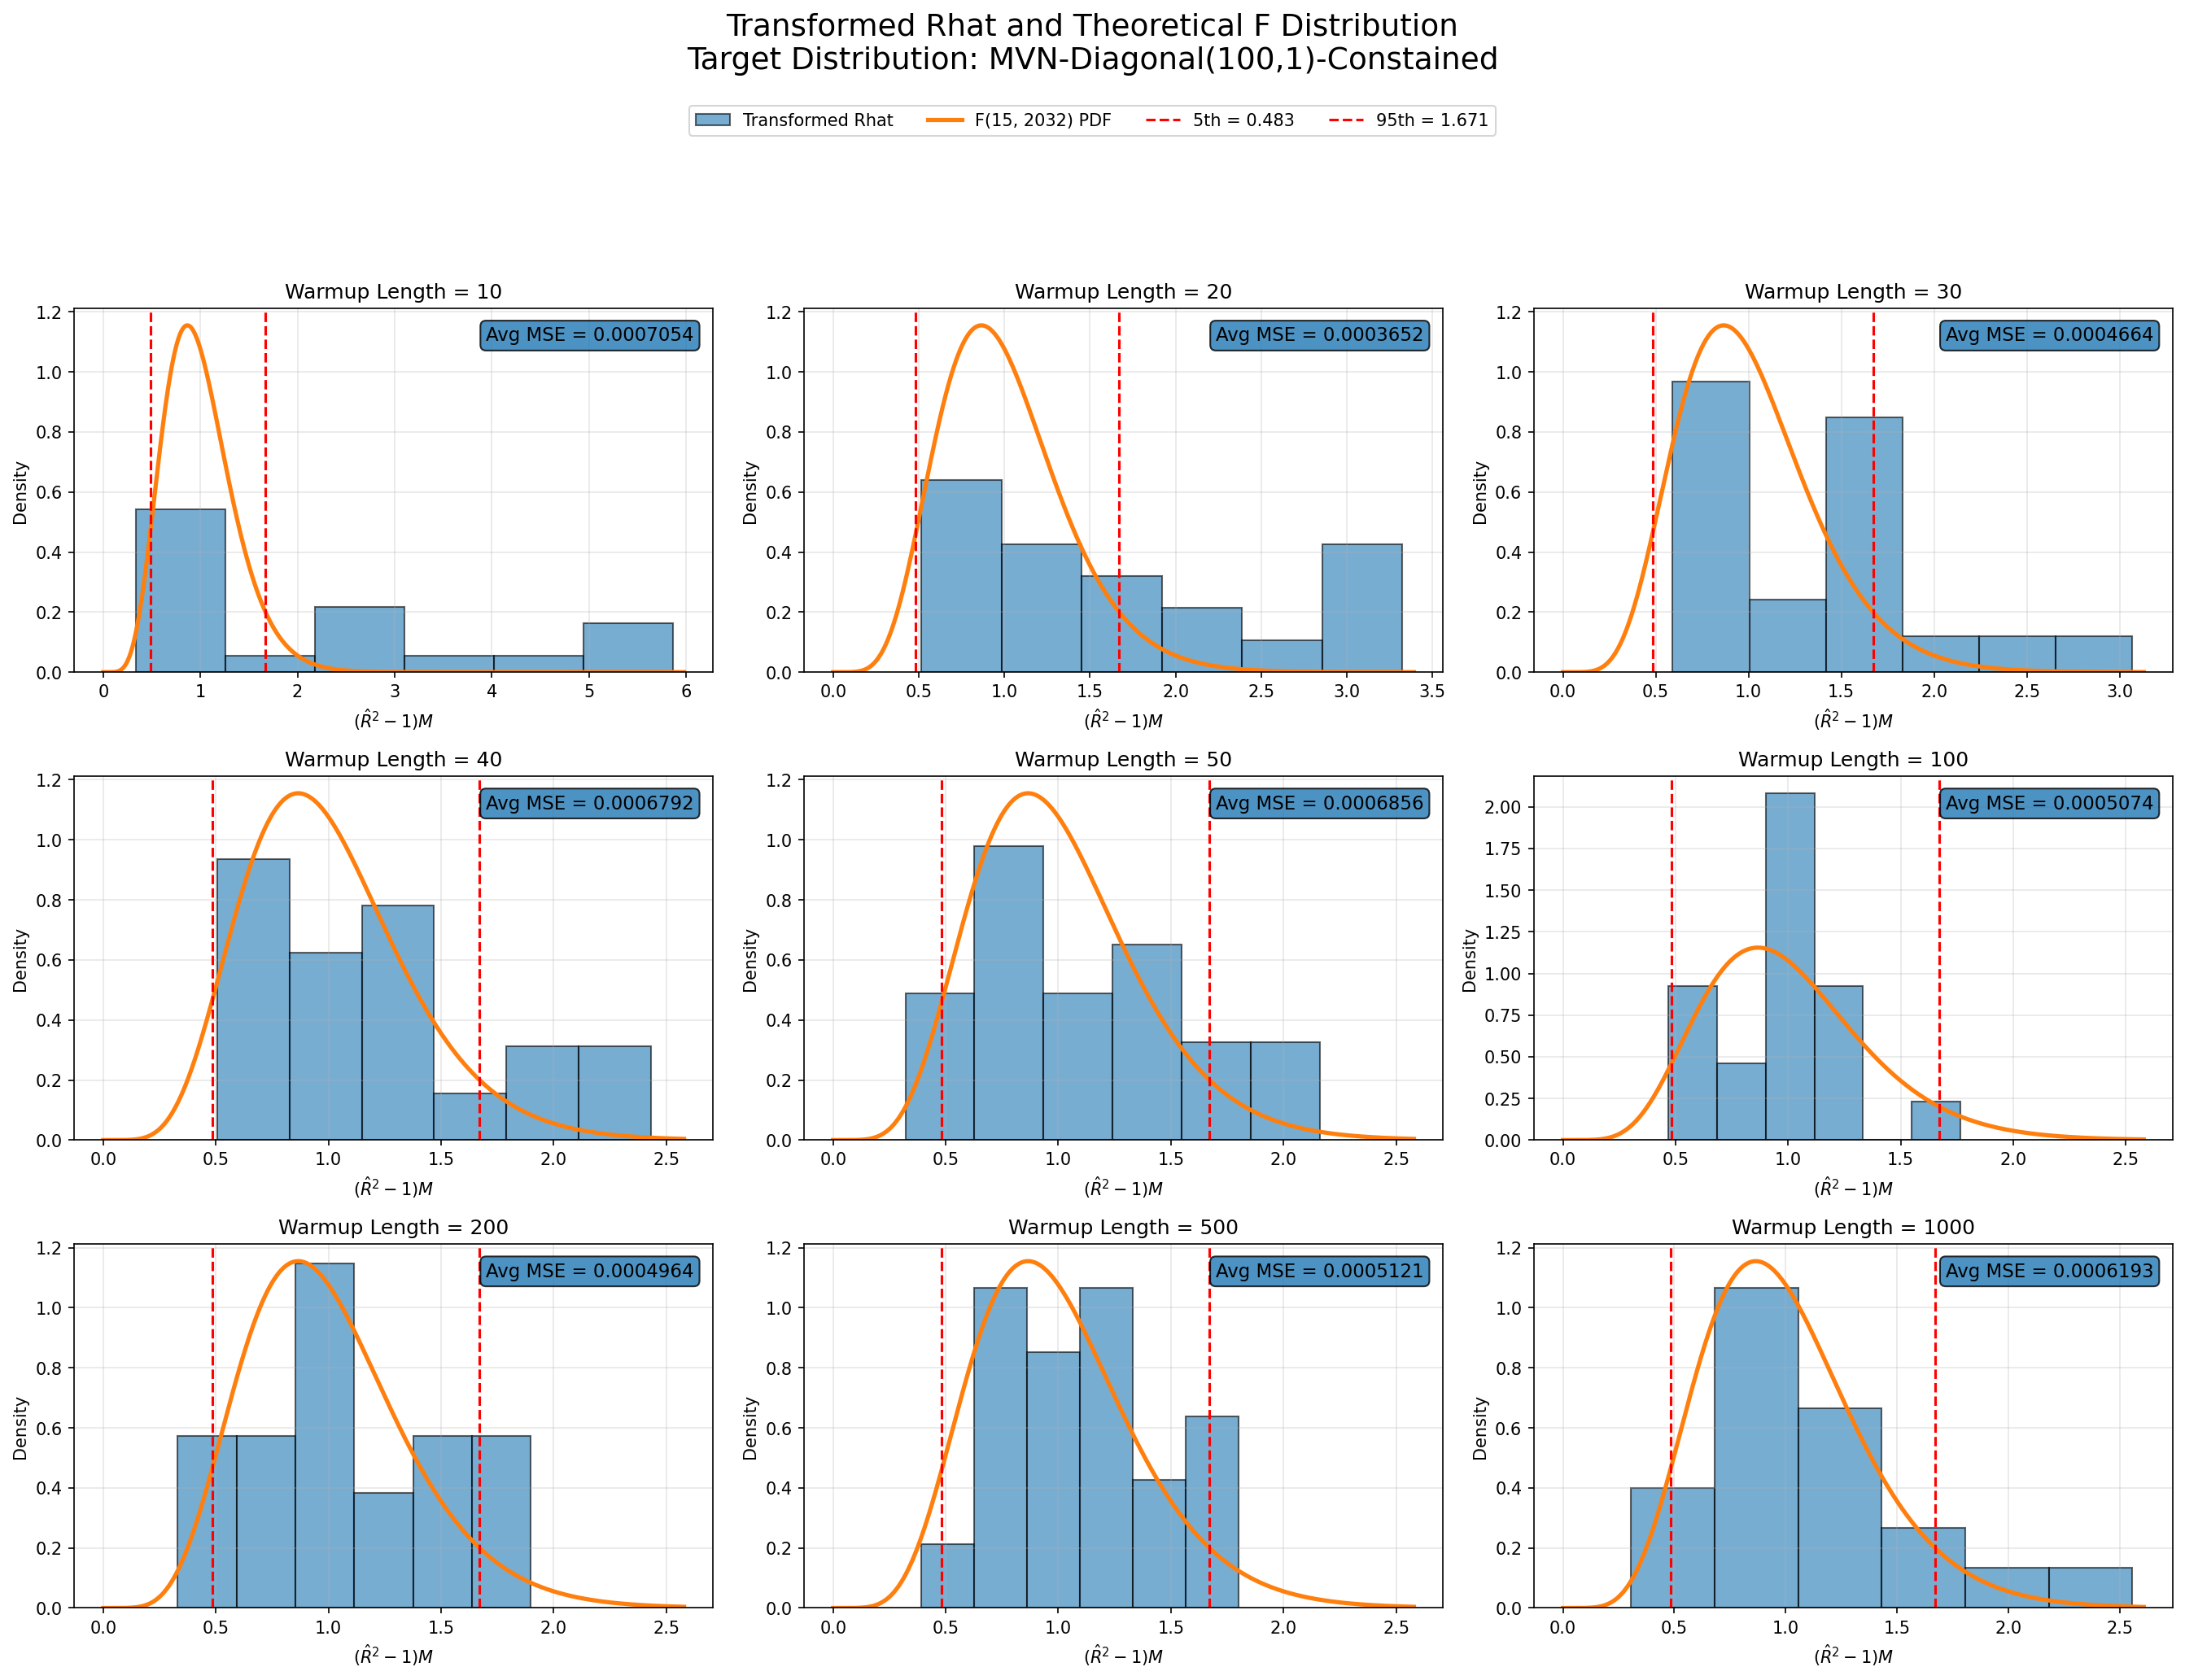

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_c_df,
    "MVN-Diagonal(100,1)-Constained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

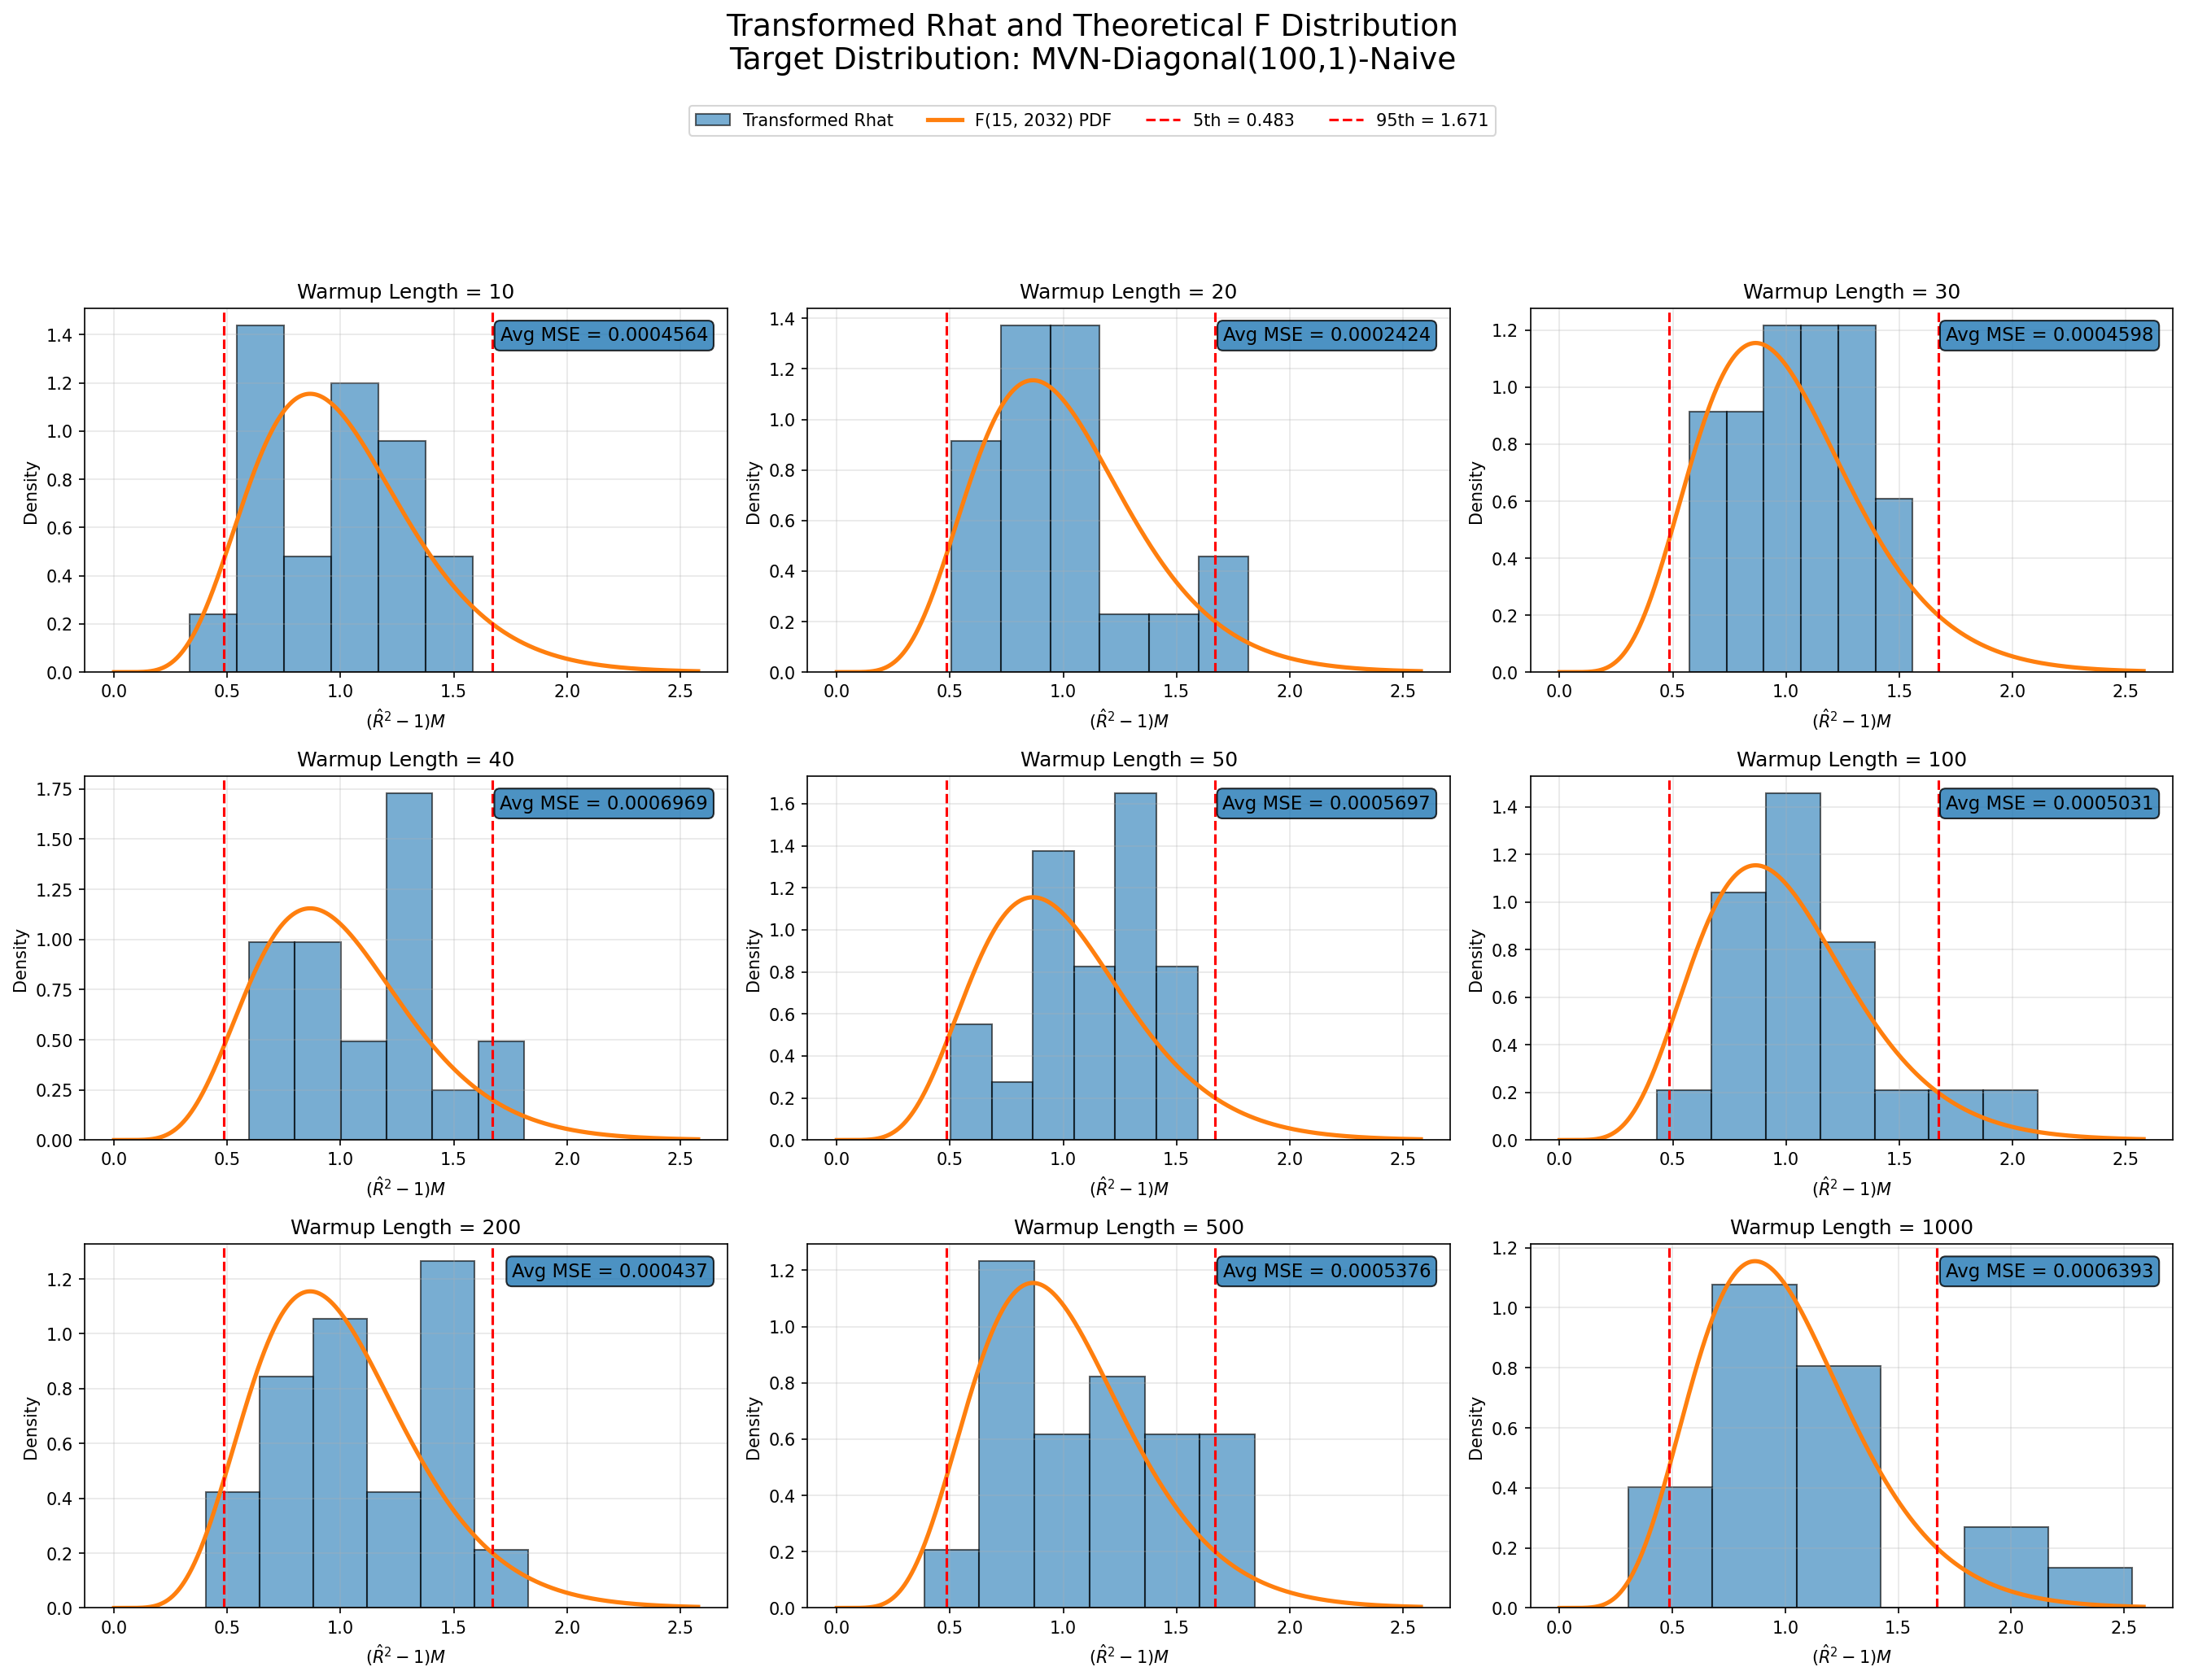

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_n_df,
    "MVN-Diagonal(100,1)-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

In [ ]:
# MSE vs nested Rhat:
R_Hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_1000_1_Rhat_c.pkl"
R_Hat_c_df = pd.read_pickle(R_Hat_c_path)

R_Hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/GeometryExperiment/Diag_1000_1_Rhat_n.pkl"
R_Hat_n_df = pd.read_pickle(R_Hat_n_path)

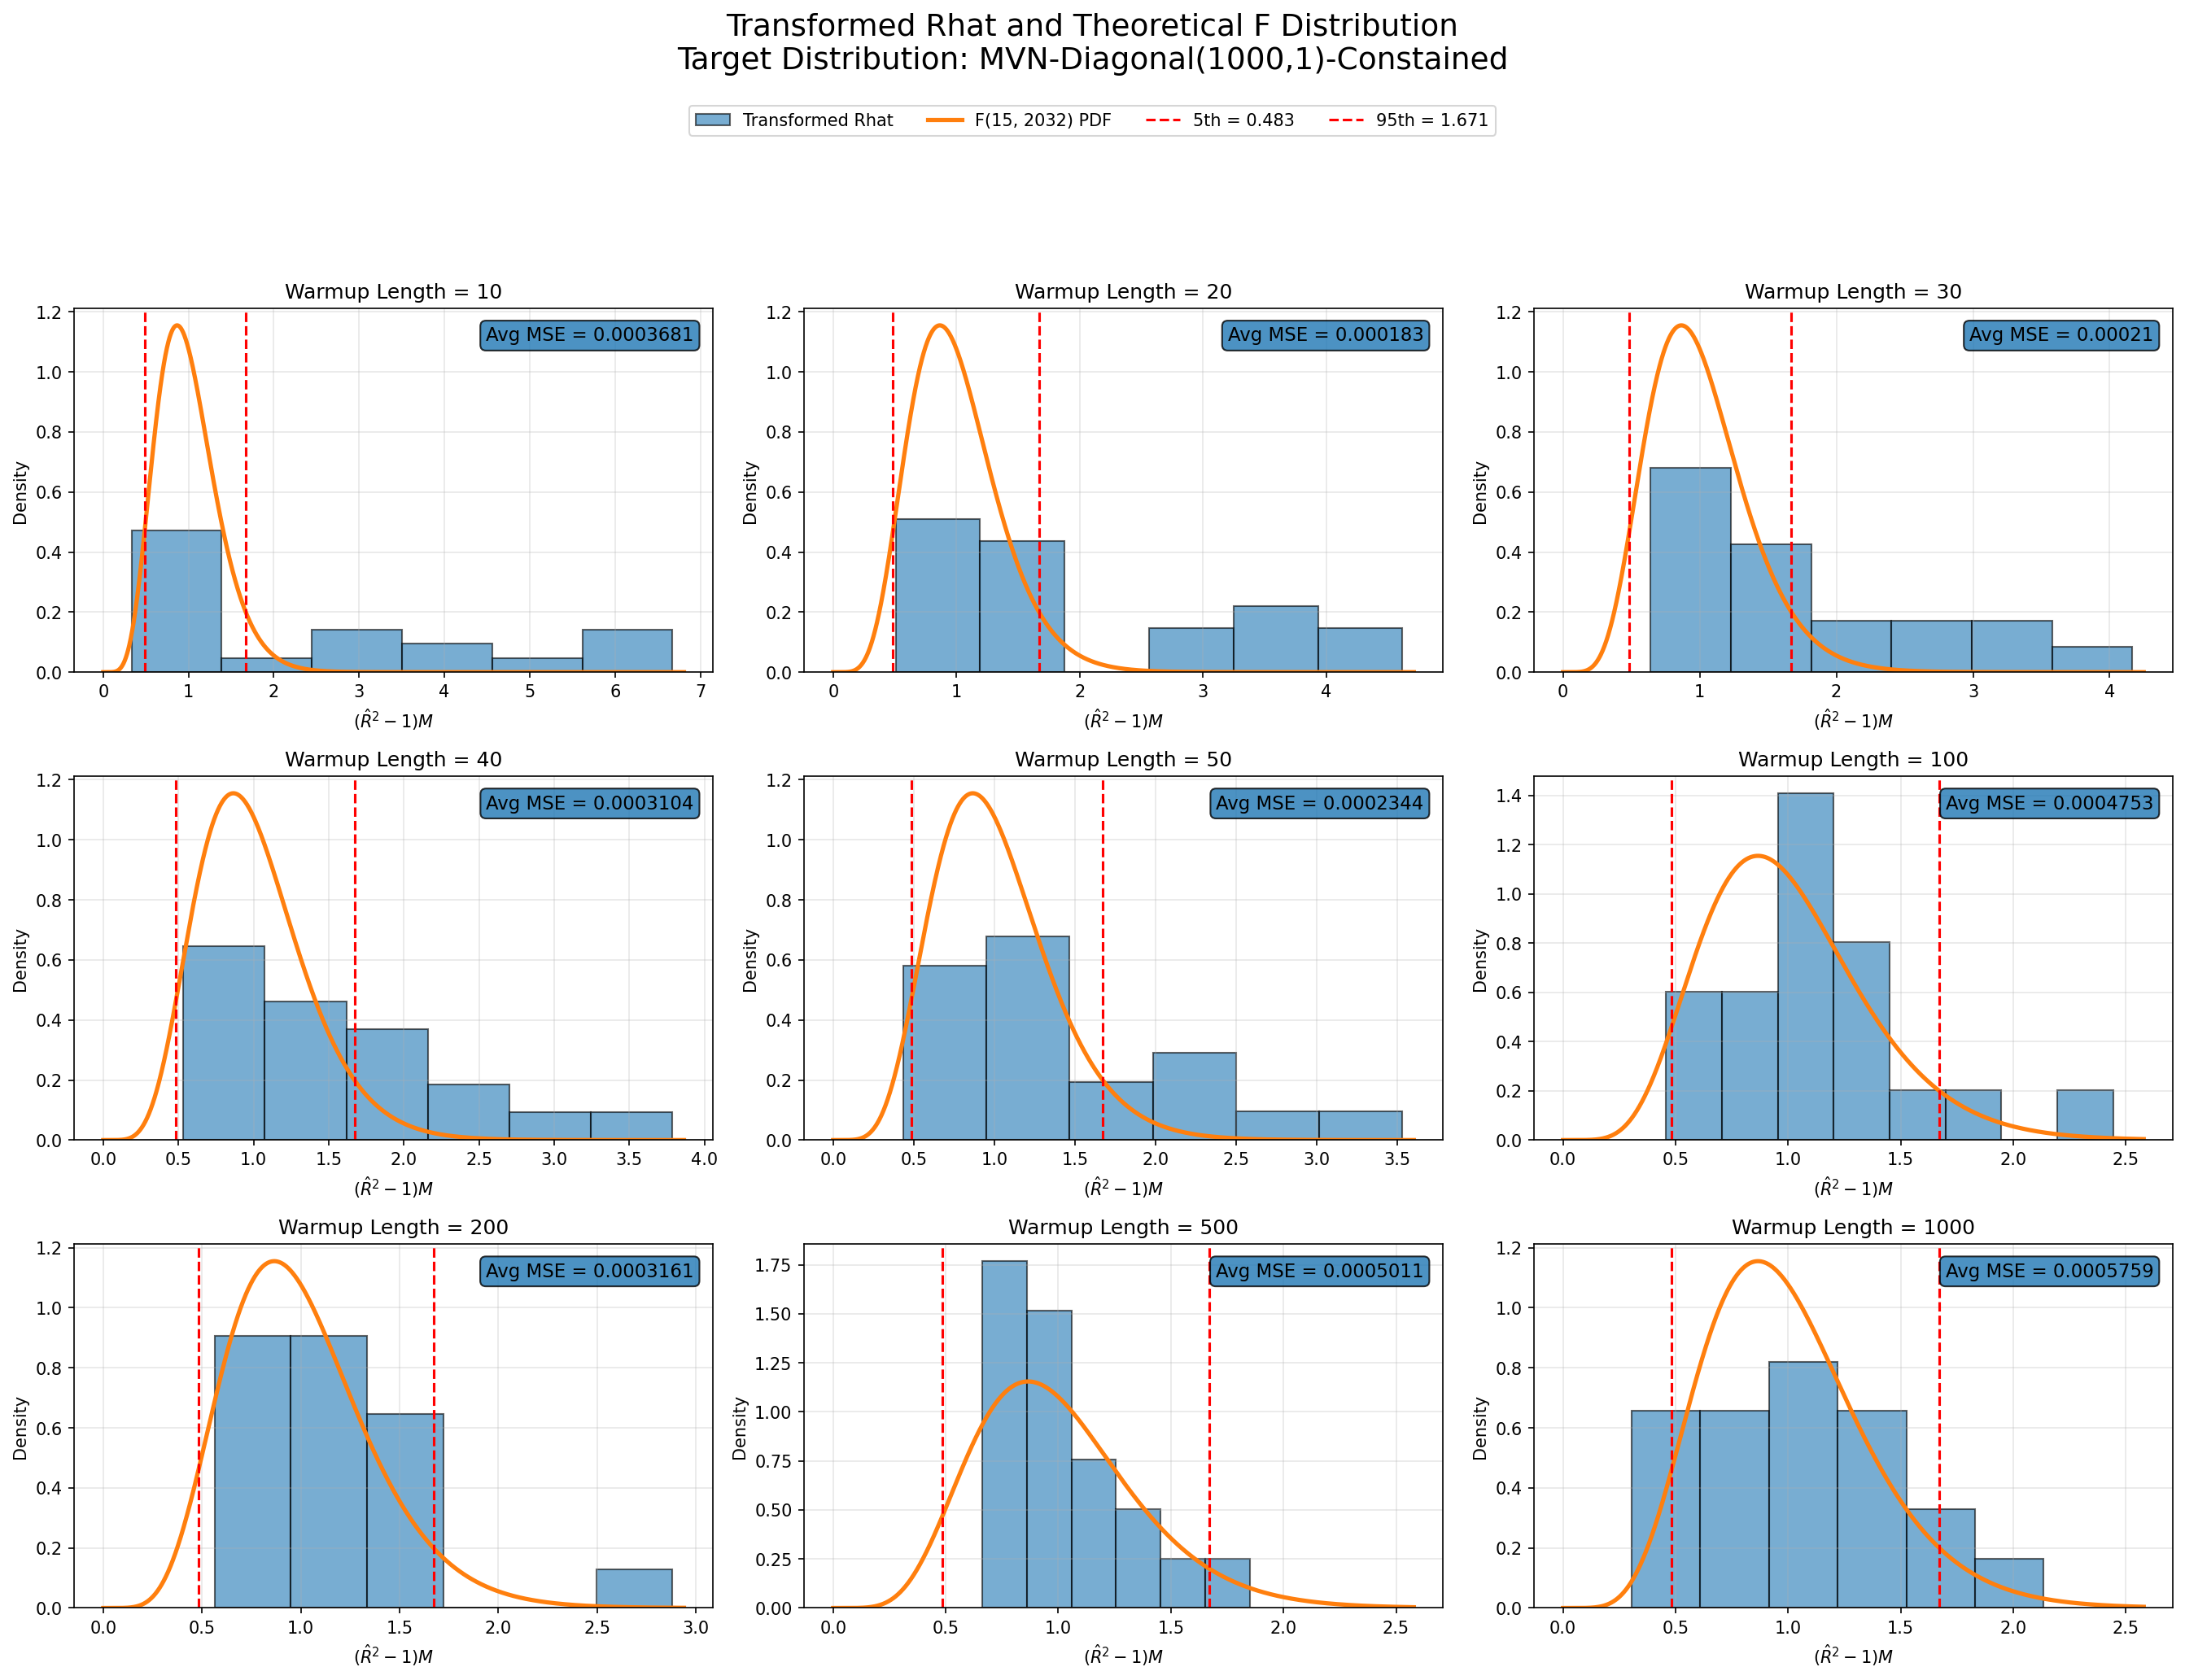

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_c_df,
    "MVN-Diagonal(1000,1)-Constained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

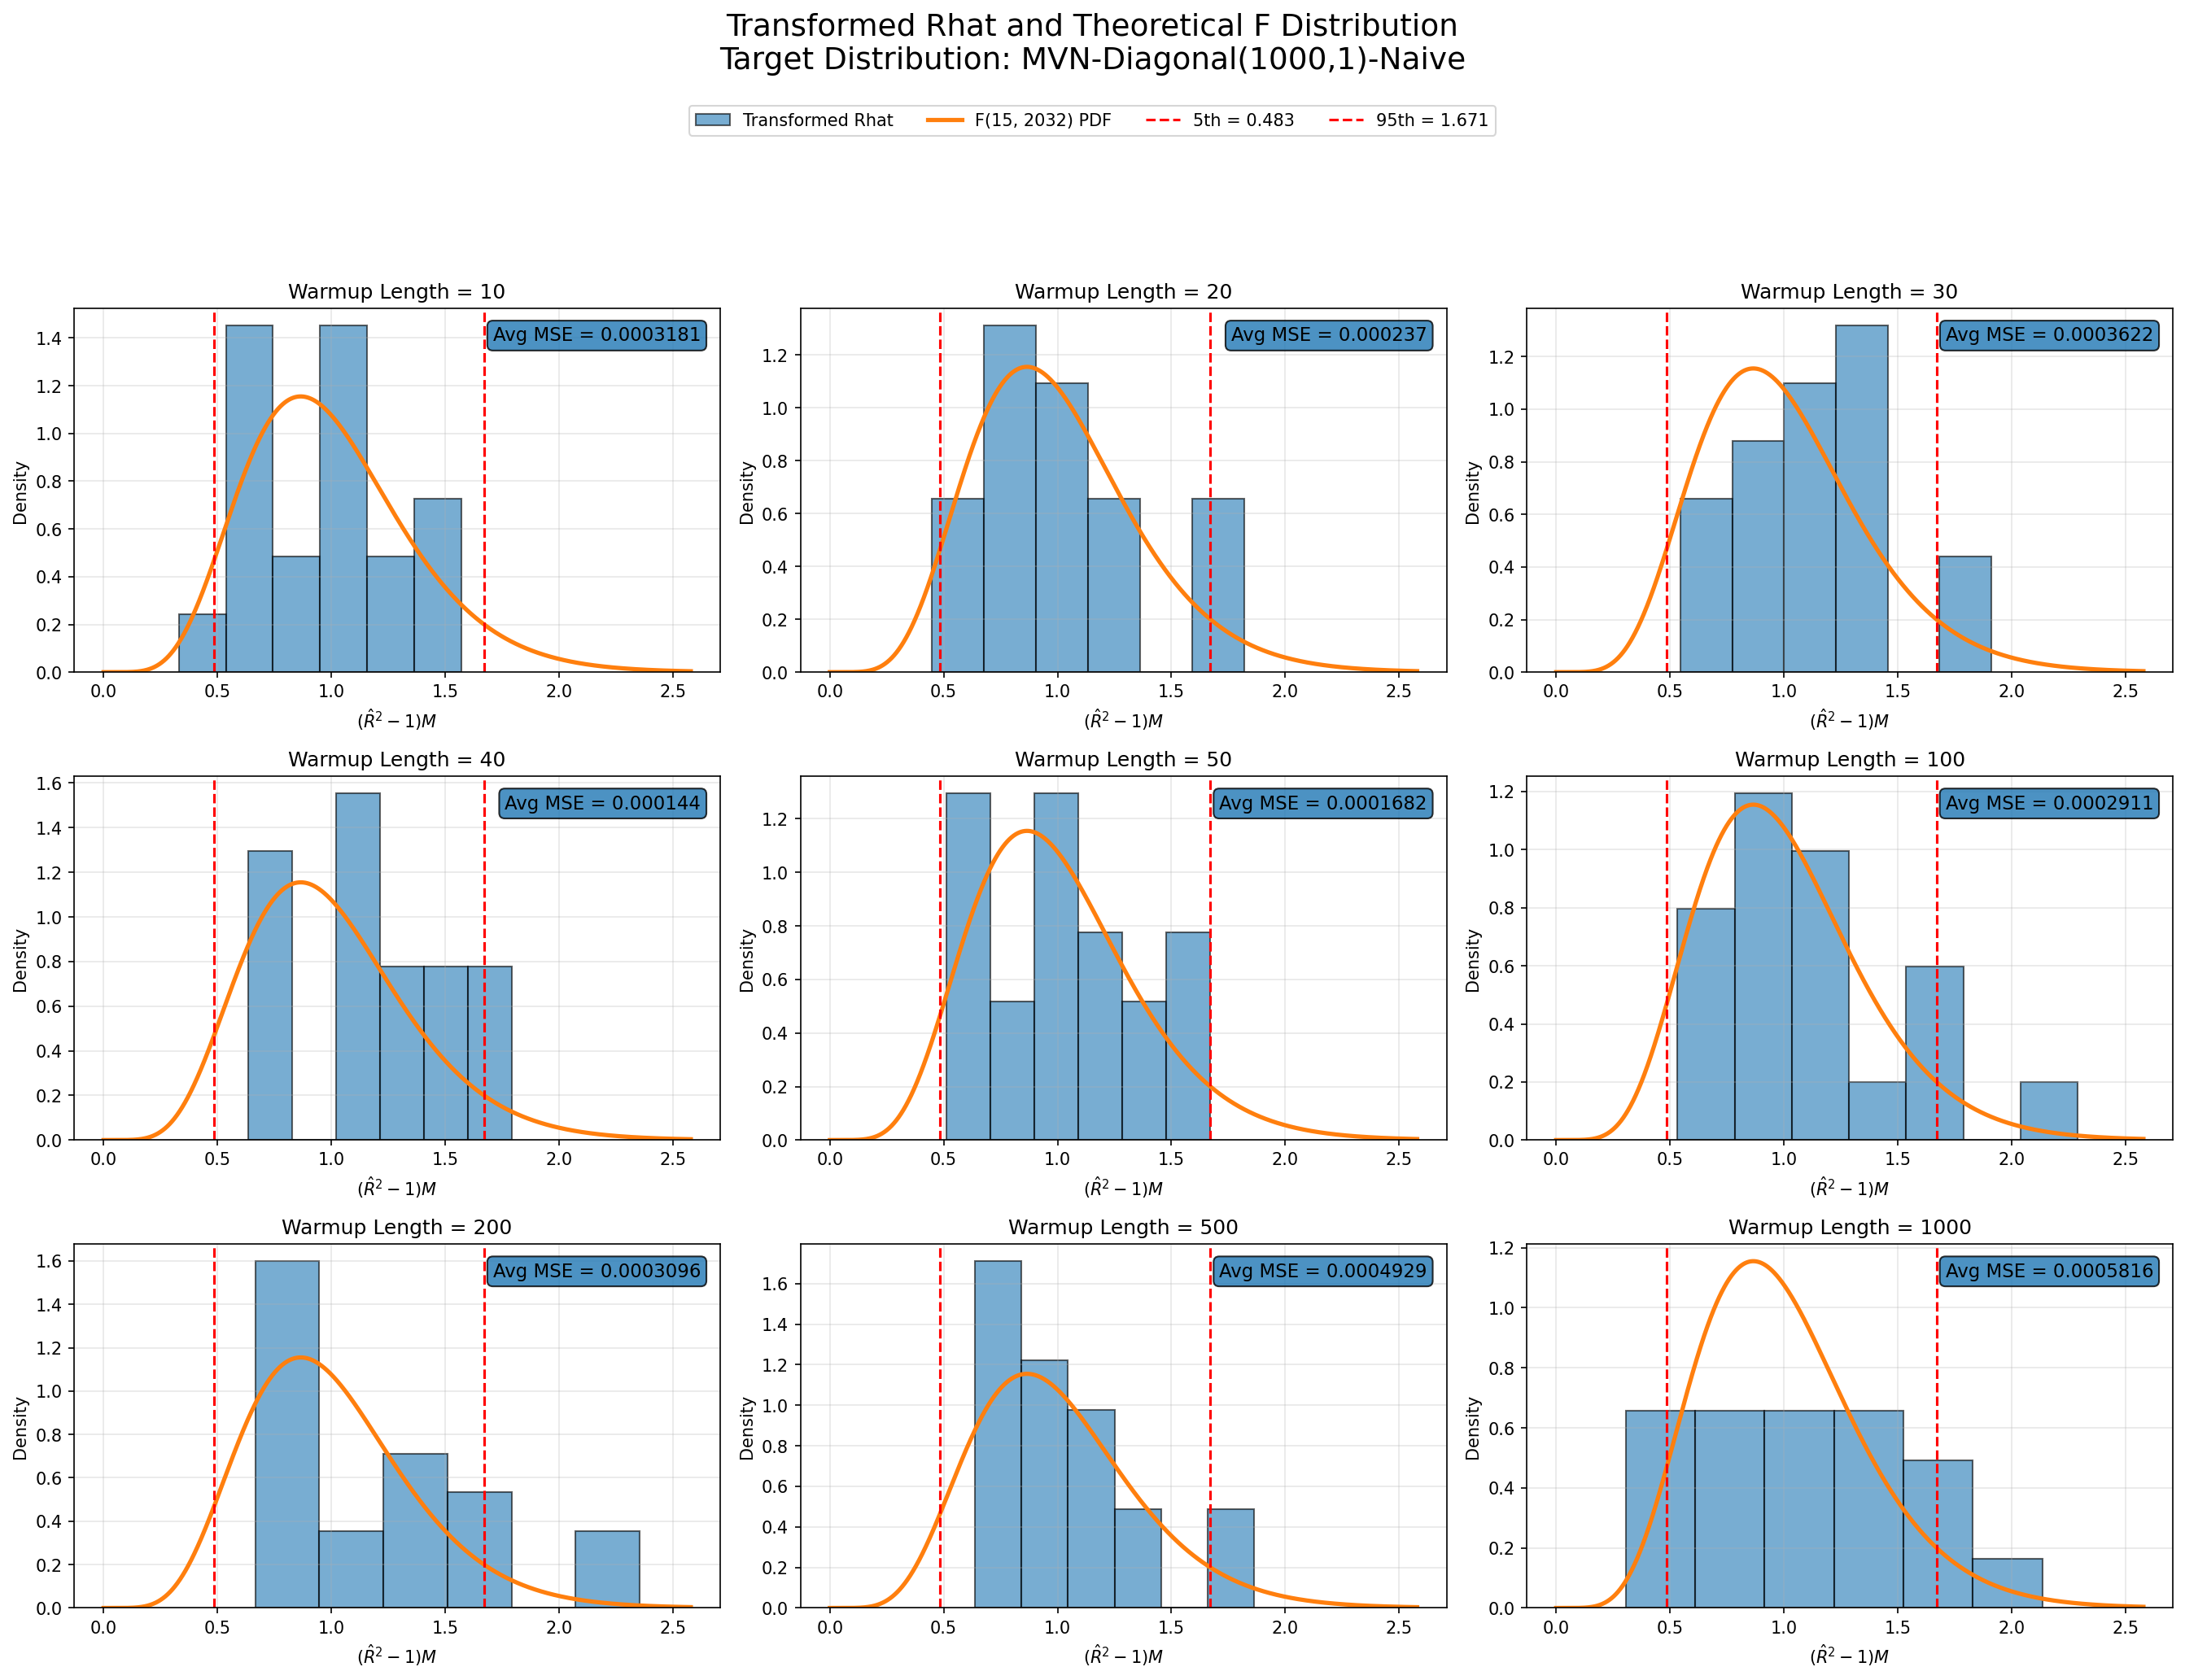

In [ ]:
plot_transformed_rhat_with_f(
    R_Hat_n_df,
    "MVN-Diagonal(1000,1)-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

## **MVN Experiments**

Isotropic Distribution

In [ ]:
# Isotropic MVN distribution
Iso_R_hat_c_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_Rhat_c.pkl"
Iso_R_Hat_c_df = pd.read_pickle(Iso_R_hat_c_path)

Iso_R_hat_n_path = "/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Additional_Experiment/DimensionExperiment/Iso_Rhat_n.pkl"
Iso_R_Hat_n_df = pd.read_pickle(Iso_R_hat_n_path)
print("Isotropic covariance data Loaded!")

Isotropic covariance data Loaded!


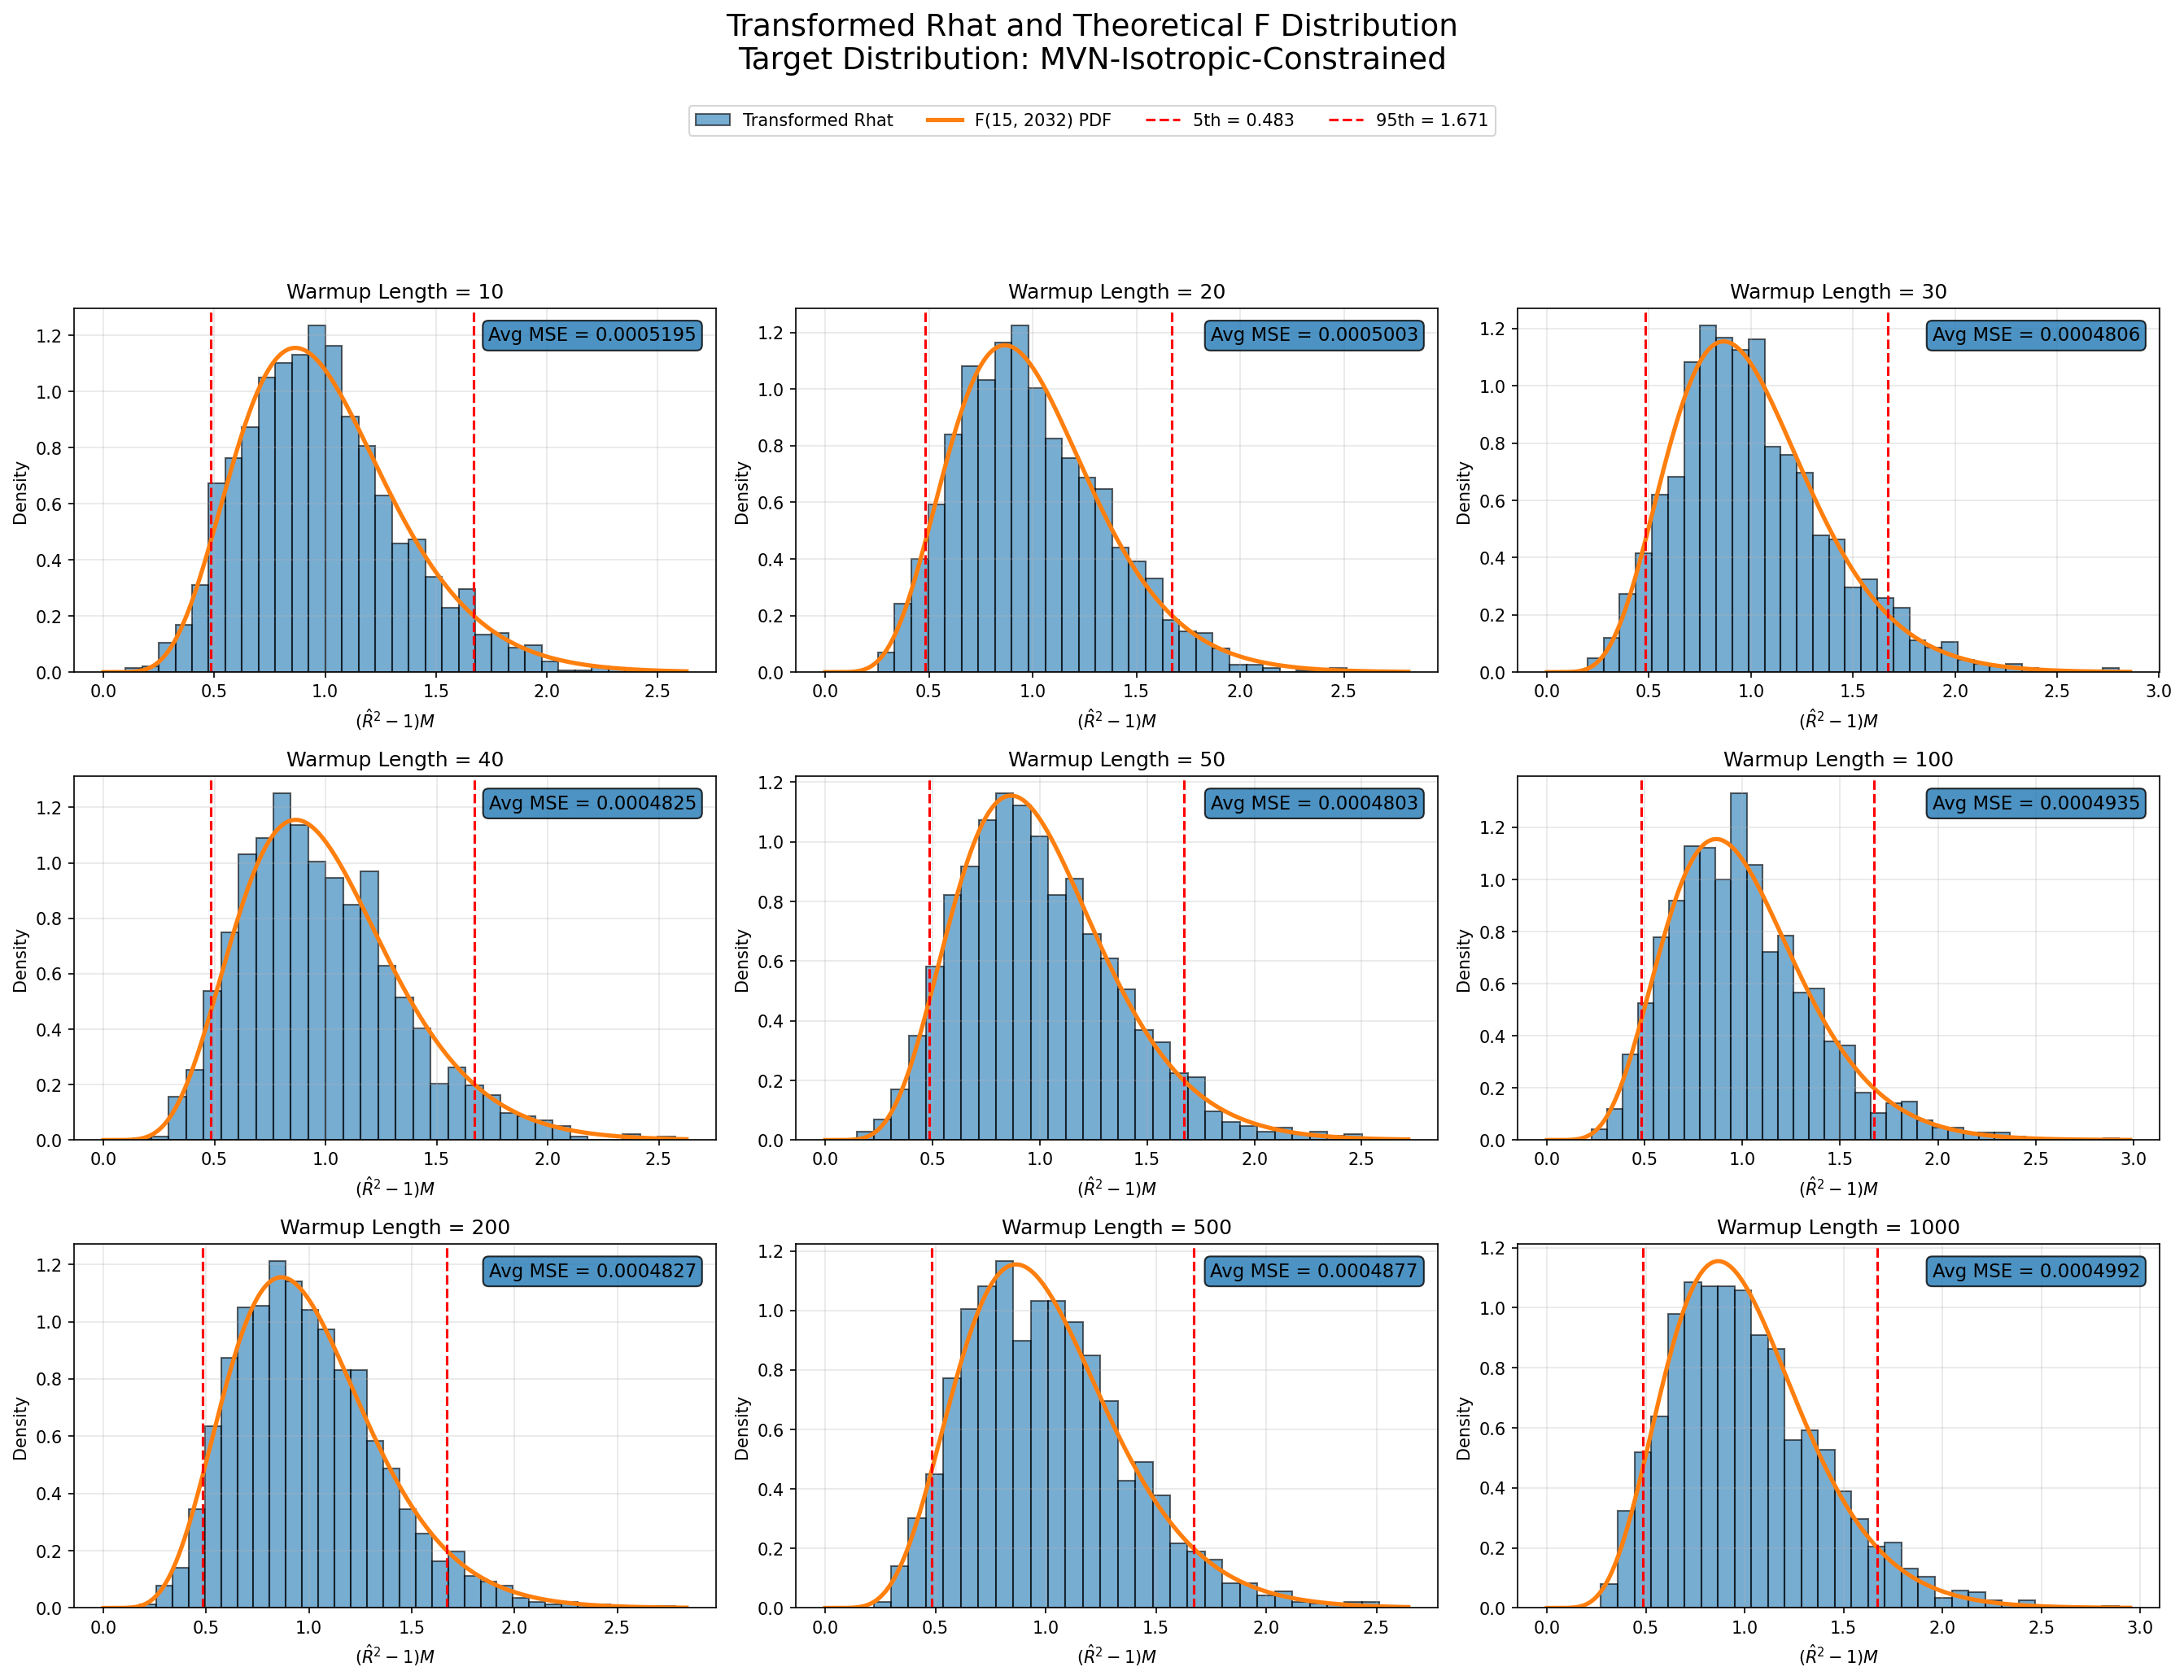

In [ ]:
plot_transformed_rhat_with_f(
    Iso_R_Hat_c_df,
    "MVN-Isotropic-Constrained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto" # used to be 250
)

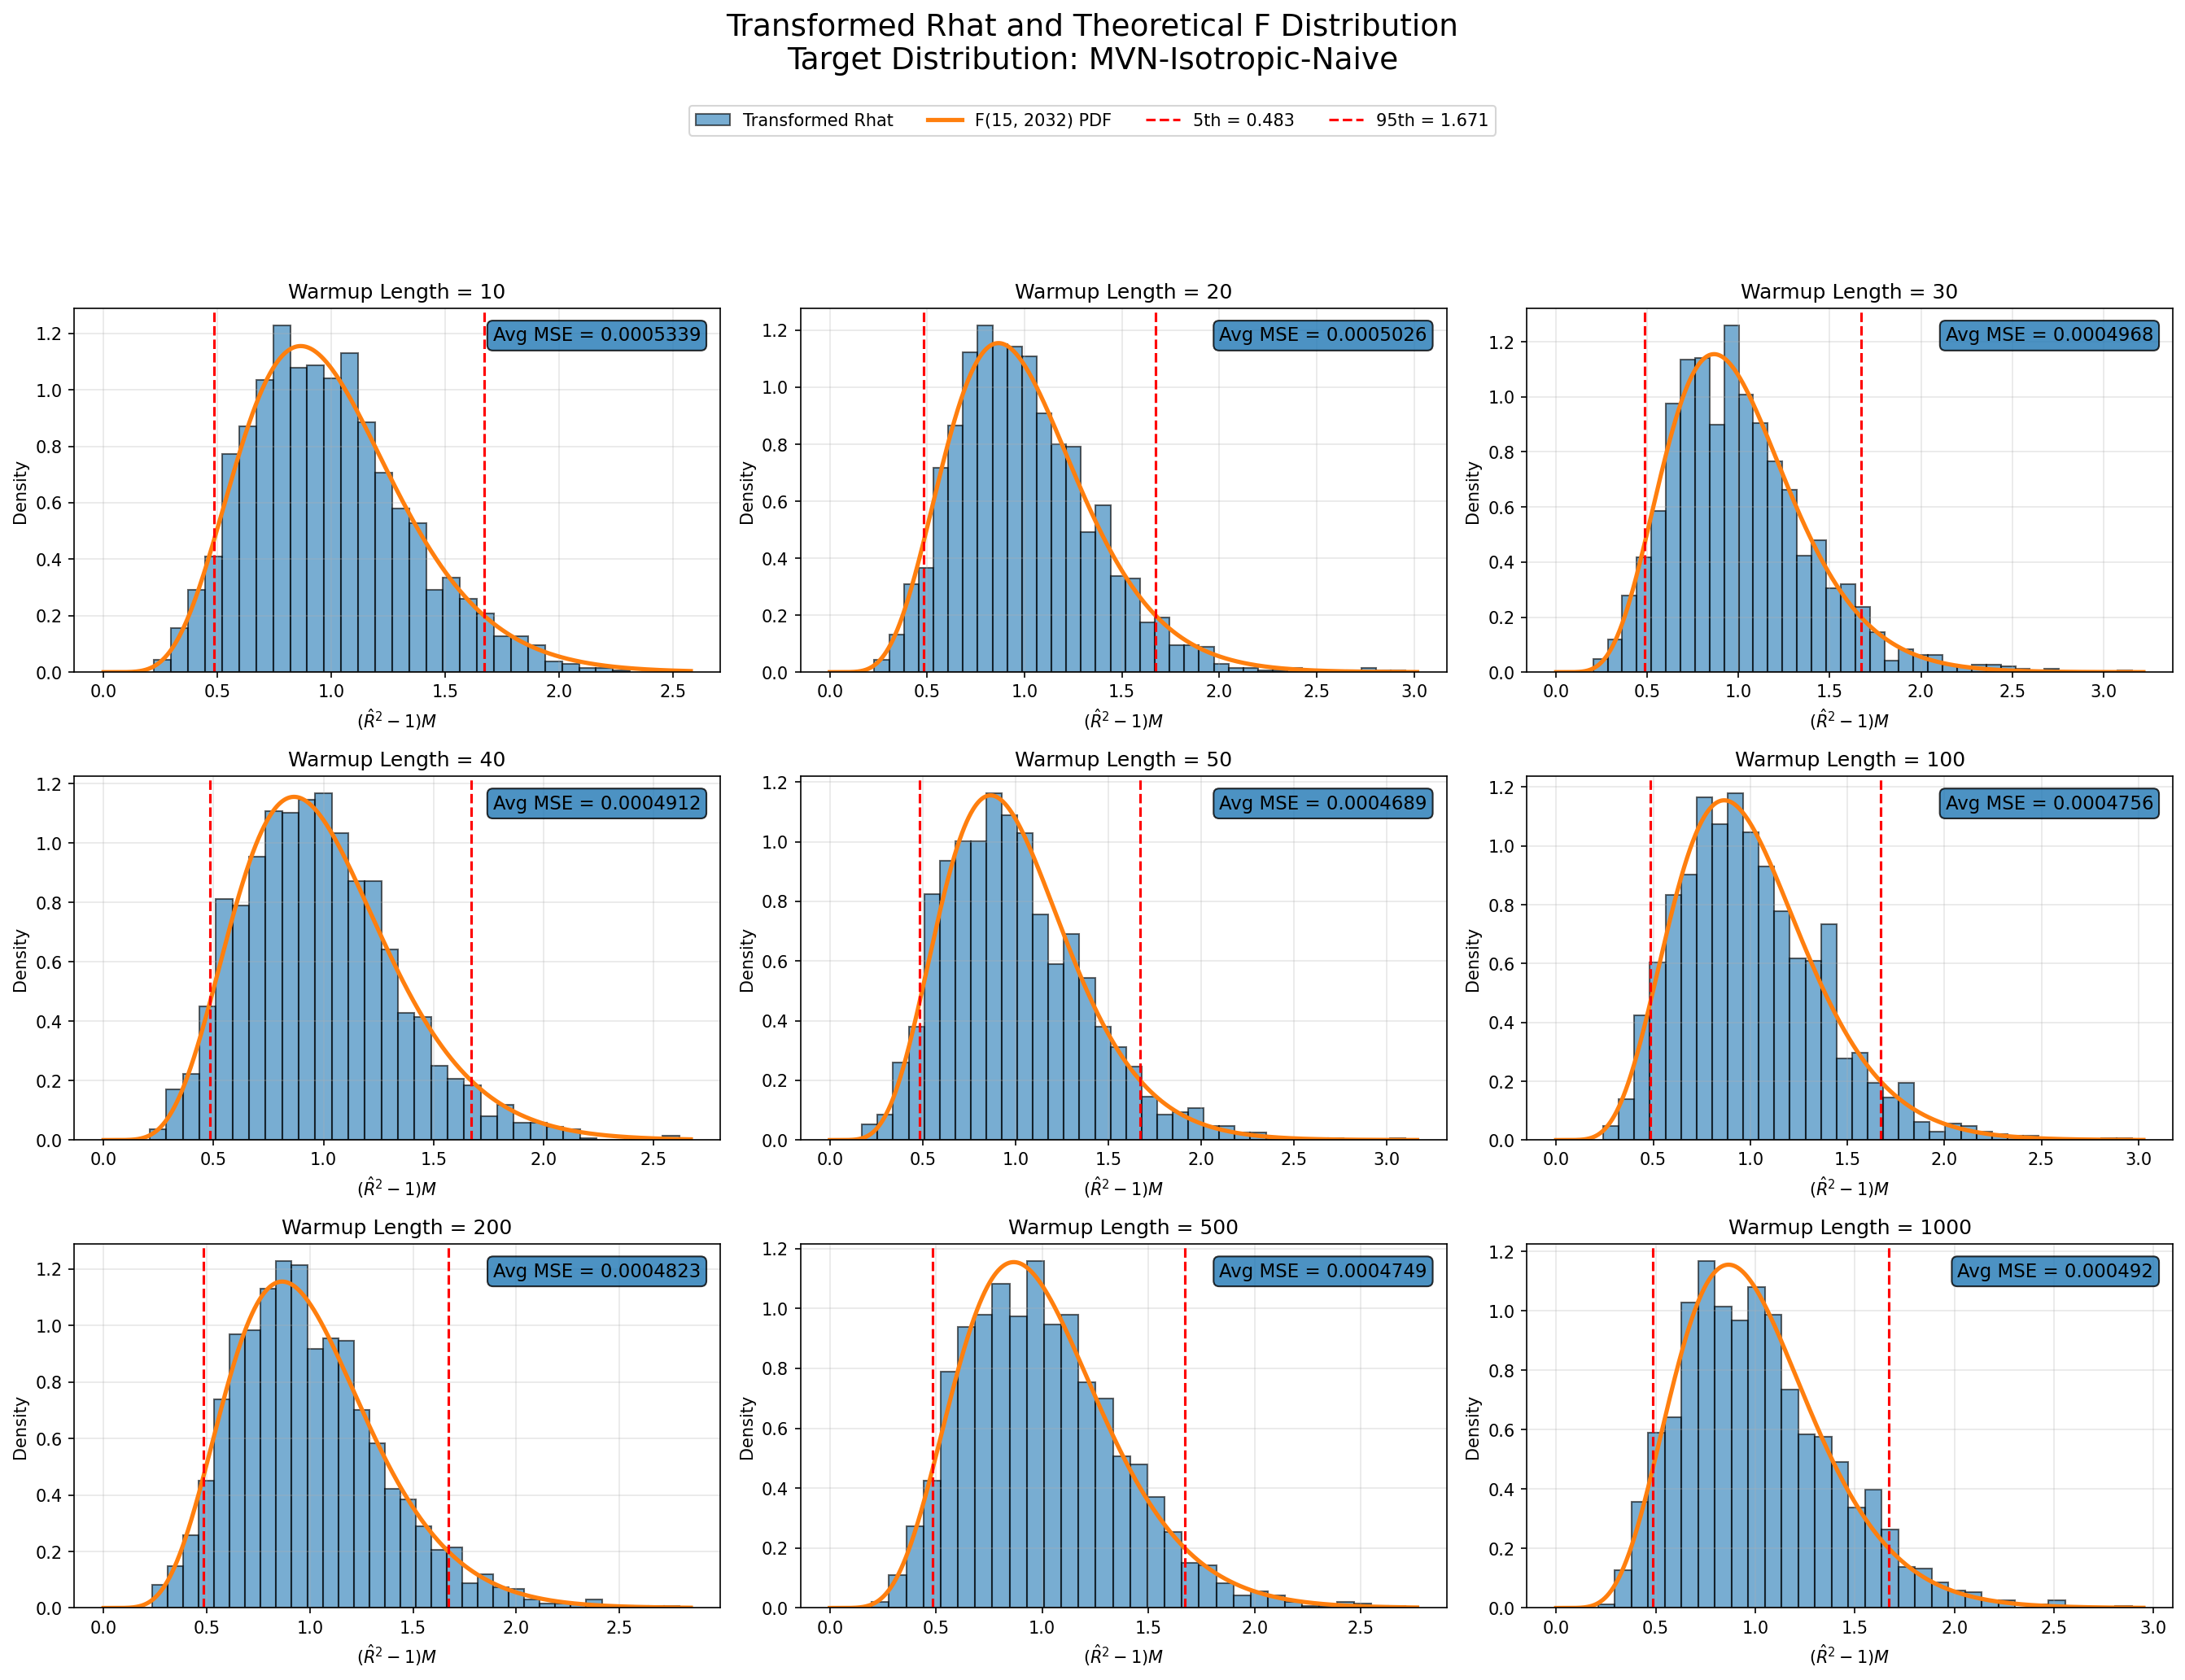

In [ ]:
plot_transformed_rhat_with_f(
    Iso_R_Hat_n_df,
    "MVN-Isotropic-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto" # used to be 250
)

AR(1) Distribution:

In [ ]:
AR_R_hat_c_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/MVN_pkl_files/AR_Rhat_c.pkl"
AR_R_Hat_c_df = pd.read_pickle(AR_R_hat_c_path)

AR_R_hat_n_path = "/content/drive/MyDrive/Colab Notebooks/2026_Summer_MCMC/MVN_pkl_files/AR_Rhat_n.pkl"
AR_R_Hat_n_df = pd.read_pickle(AR_R_hat_n_path)

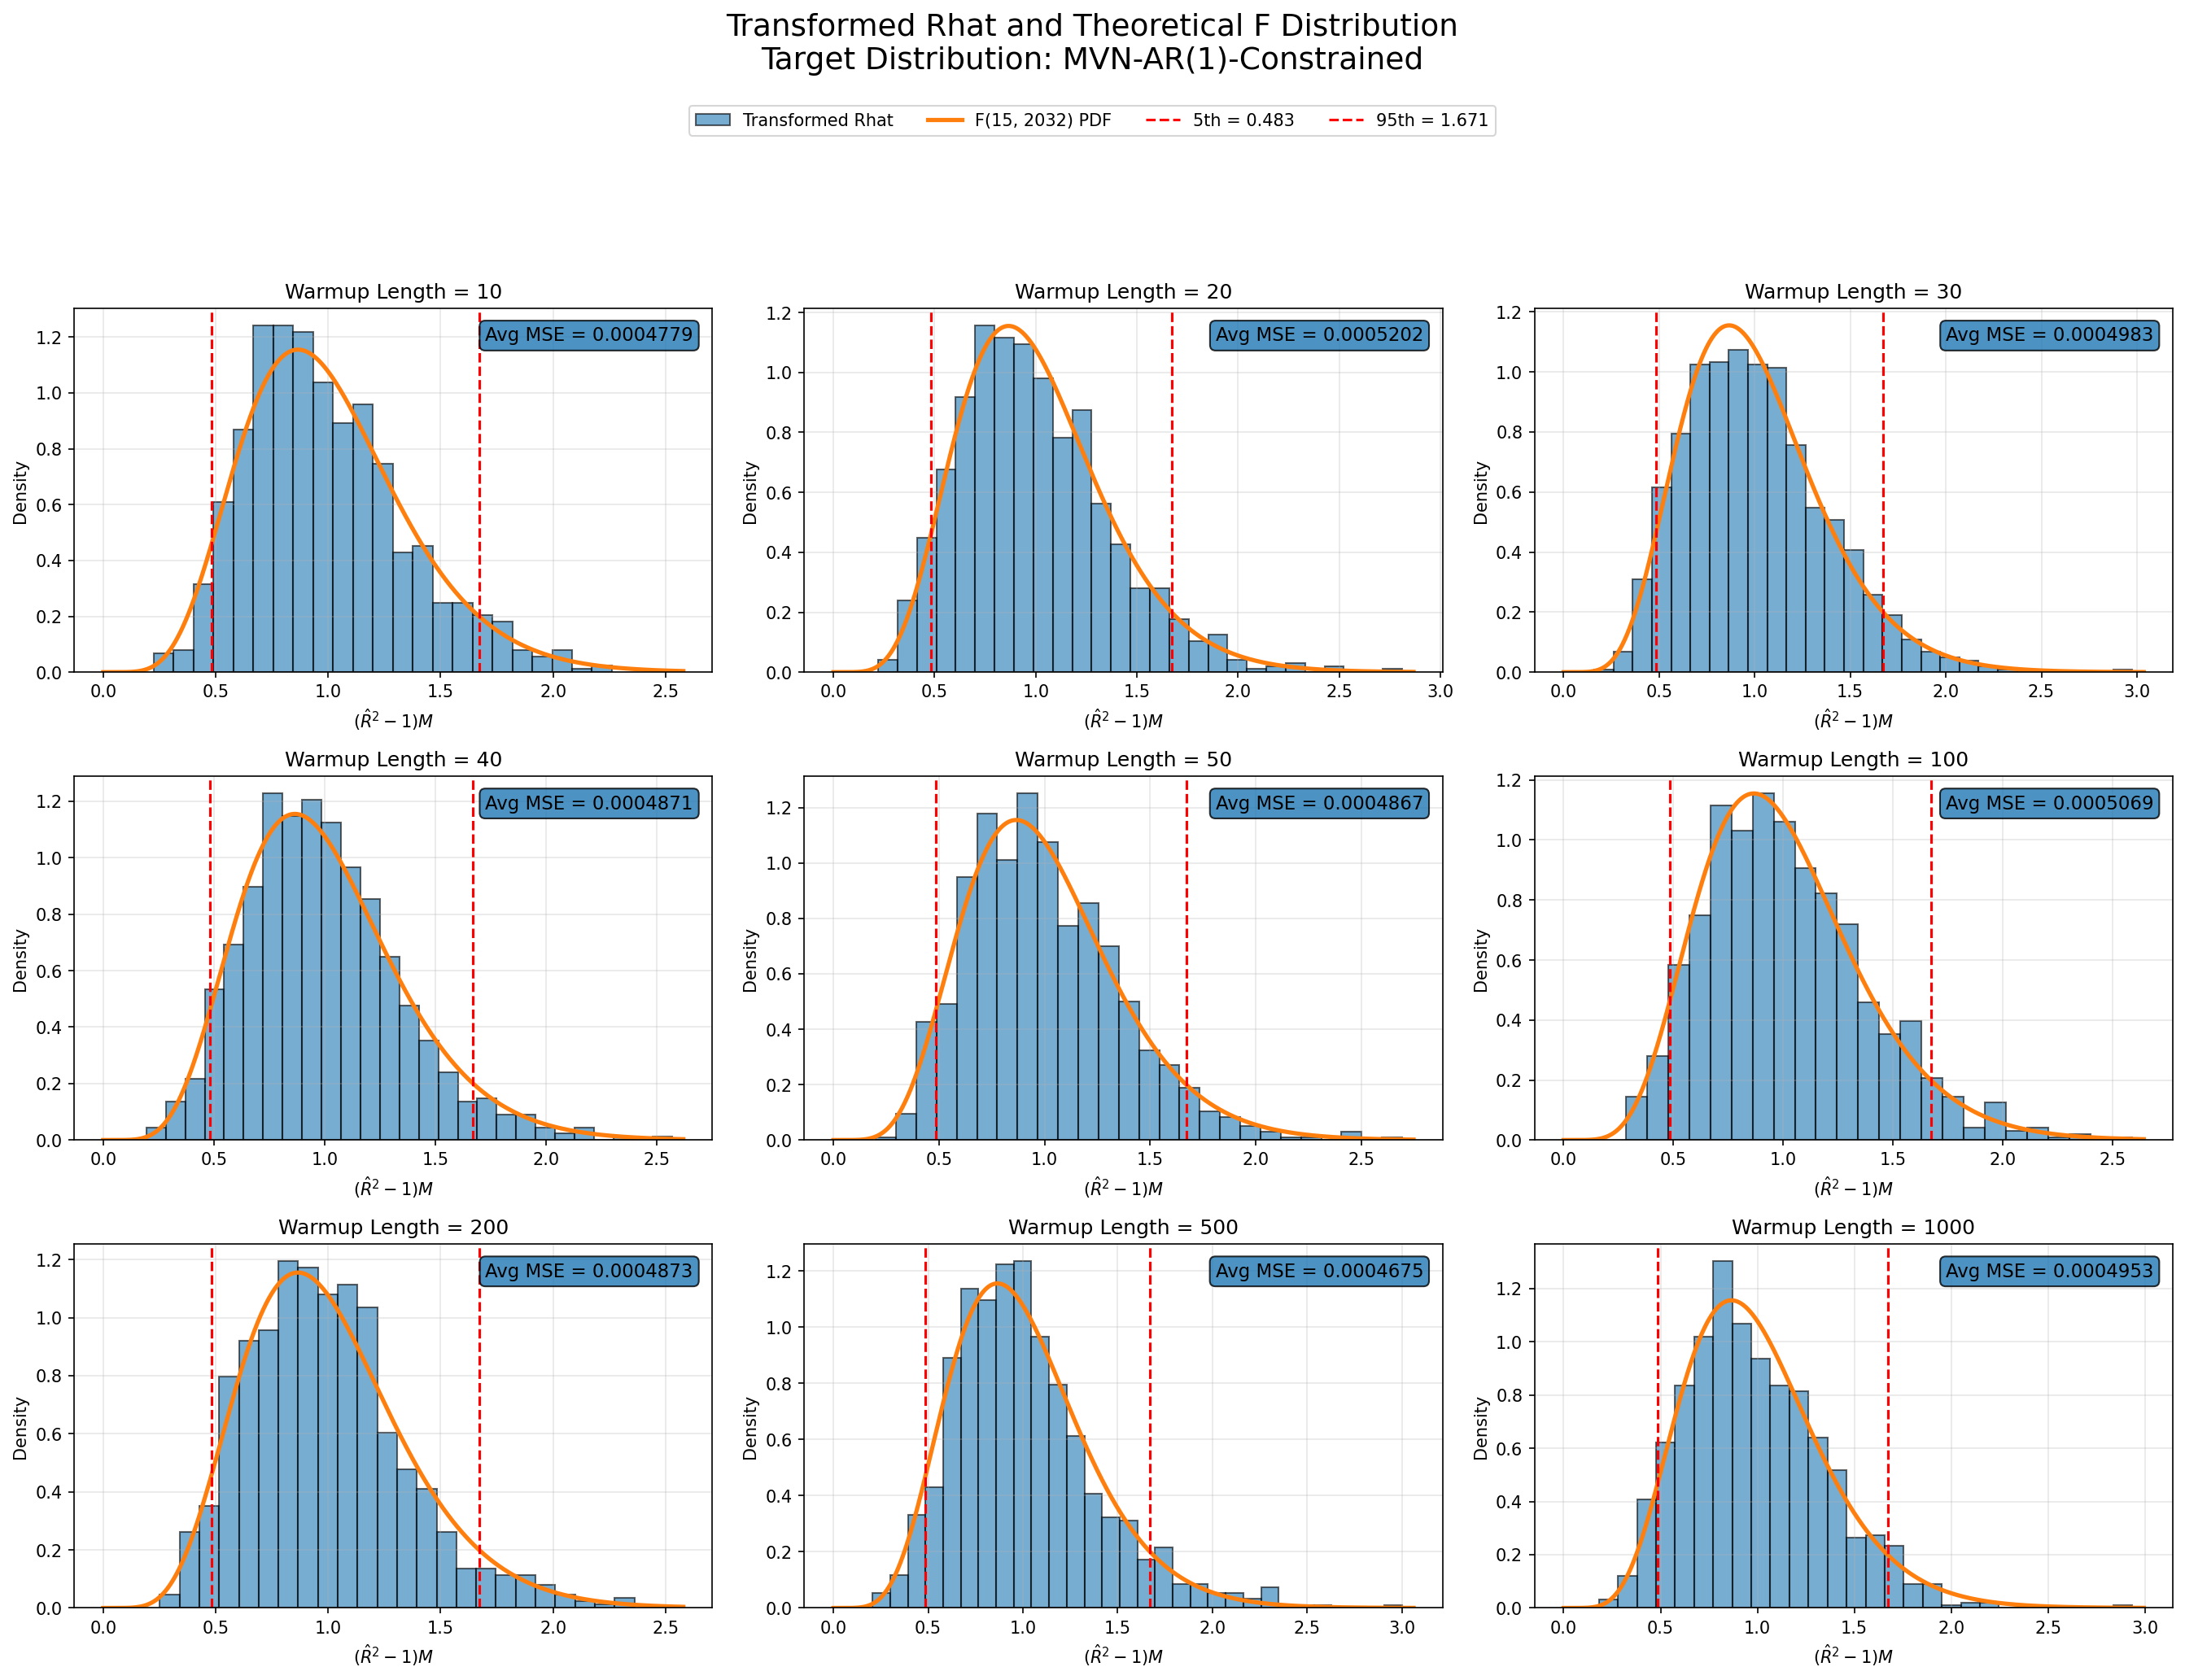

In [ ]:
plot_transformed_rhat_with_f(
    AR_R_Hat_c_df,
    "MVN-AR(1)-Constrained",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)

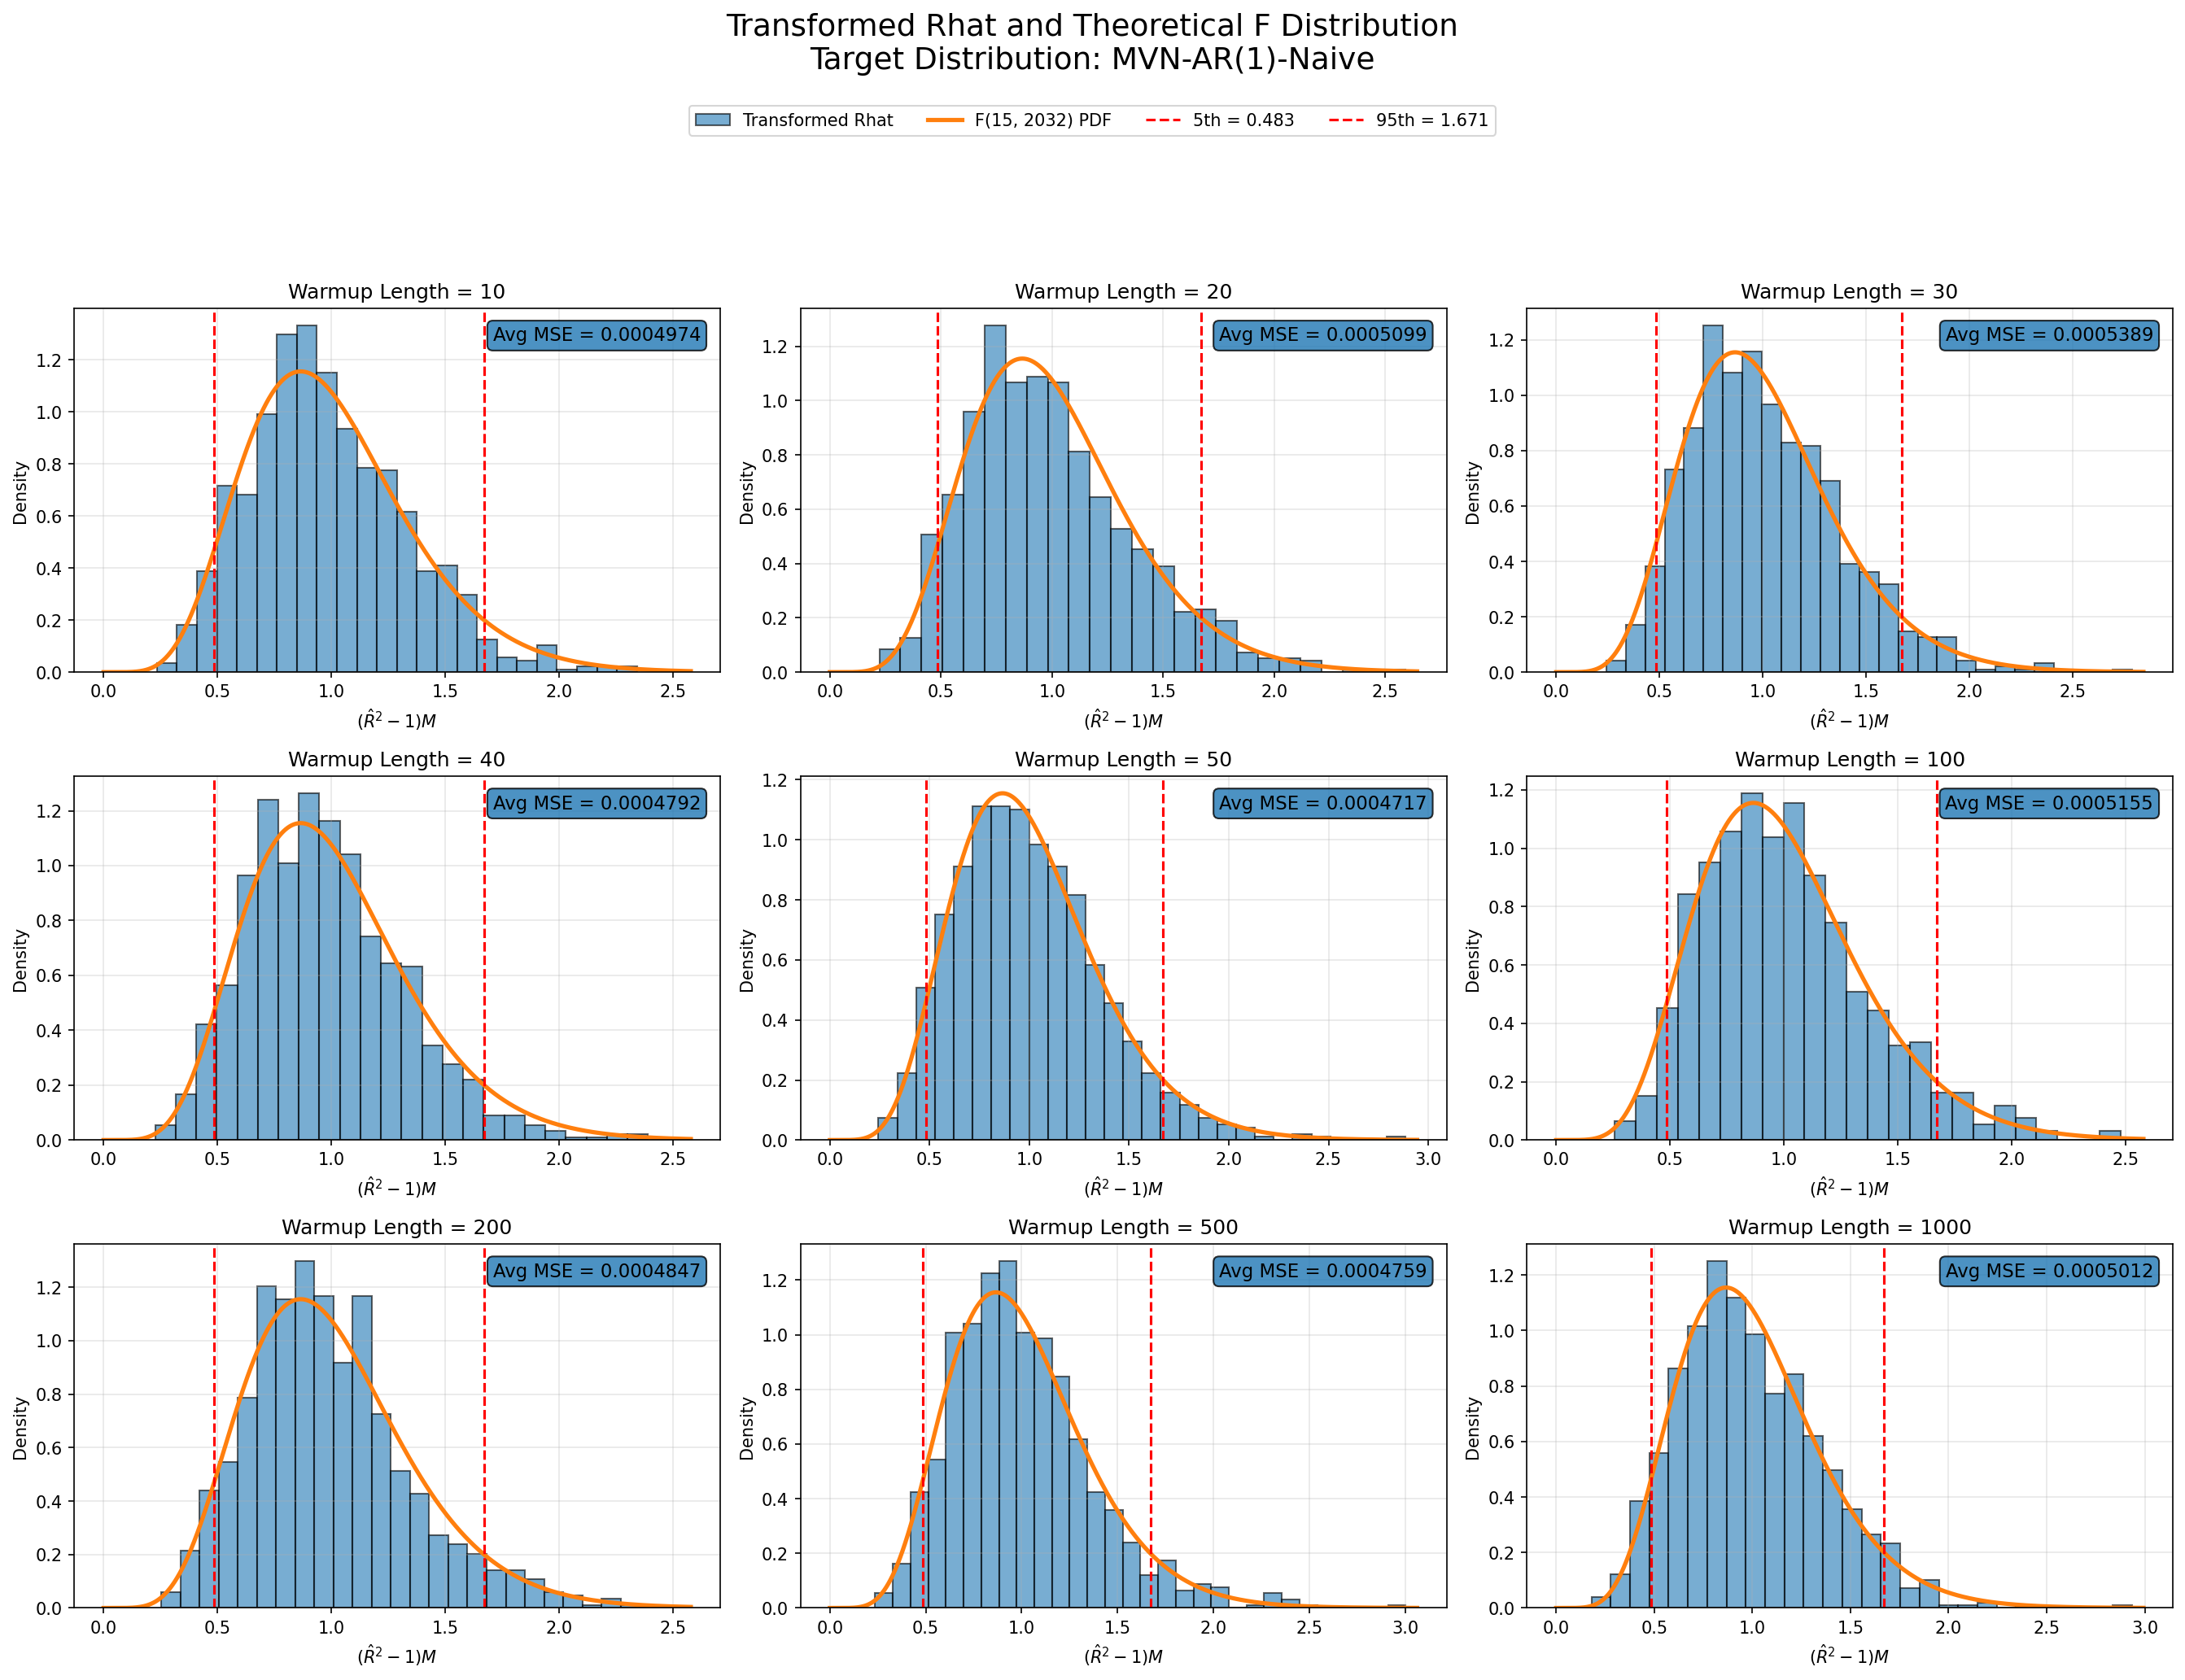

In [ ]:
plot_transformed_rhat_with_f(
    AR_R_Hat_n_df,
    "MVN-AR(1)-Naive",
    num_super_chains,
    num_chains_short // num_super_chains,
    warmup_lengths,
    bins="auto"
)